In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import astropy.units as u
import os
import pandas as pd
from astroquery.jplsbdb import SBDB

import phunk
from sbpy import photometry as phot
import lmfit
from scipy.interpolate import CubicSpline
from scipy import stats

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pickle
from matplotlib import colormaps

## custom functions
from Asteroid_pickle import *
from asteroid_ls import *

# Splitting by opposition

P07G
D29R
703G
703V
M22o
C57G
W68o
G96G
G96V
G45r
F51w
T08o
T05c
T05o
Detected opposition epochs from Horizons:
  Opp 0: JD=2453657.938, UTC=2005-10-14 10:30:21, elong=178.94 deg
  Opp 1: JD=2454202.938, UTC=2007-04-12 10:30:21, elong=179.25 deg
  Opp 2: JD=2454707.938, UTC=2008-08-29 10:30:21, elong=176.04 deg
  Opp 3: JD=2455272.938, UTC=2010-03-17 10:30:21, elong=177.52 deg
  Opp 4: JD=2455766.938, UTC=2011-07-24 10:30:21, elong=175.52 deg
  Opp 5: JD=2456339.938, UTC=2013-02-16 10:30:21, elong=176.01 deg
  Opp 6: JD=2456832.938, UTC=2014-06-24 10:30:21, elong=176.30 deg
  Opp 7: JD=2457399.938, UTC=2016-01-12 10:30:21, elong=175.35 deg
  Opp 8: JD=2457902.938, UTC=2017-05-29 10:30:21, elong=177.58 deg
  Opp 9: JD=2458451.938, UTC=2018-11-29 10:30:21, elong=177.14 deg
  Opp 10: JD=2458973.938, UTC=2020-05-04 10:30:21, elong=179.16 deg
  Opp 11: JD=2459498.938, UTC=2021-10-11 10:30:21, elong=178.60 deg
  Opp 12: JD=2460044.938, UTC=2023-04-10 10:30:21, elong=178.95 deg
  Opp 13: JD=2

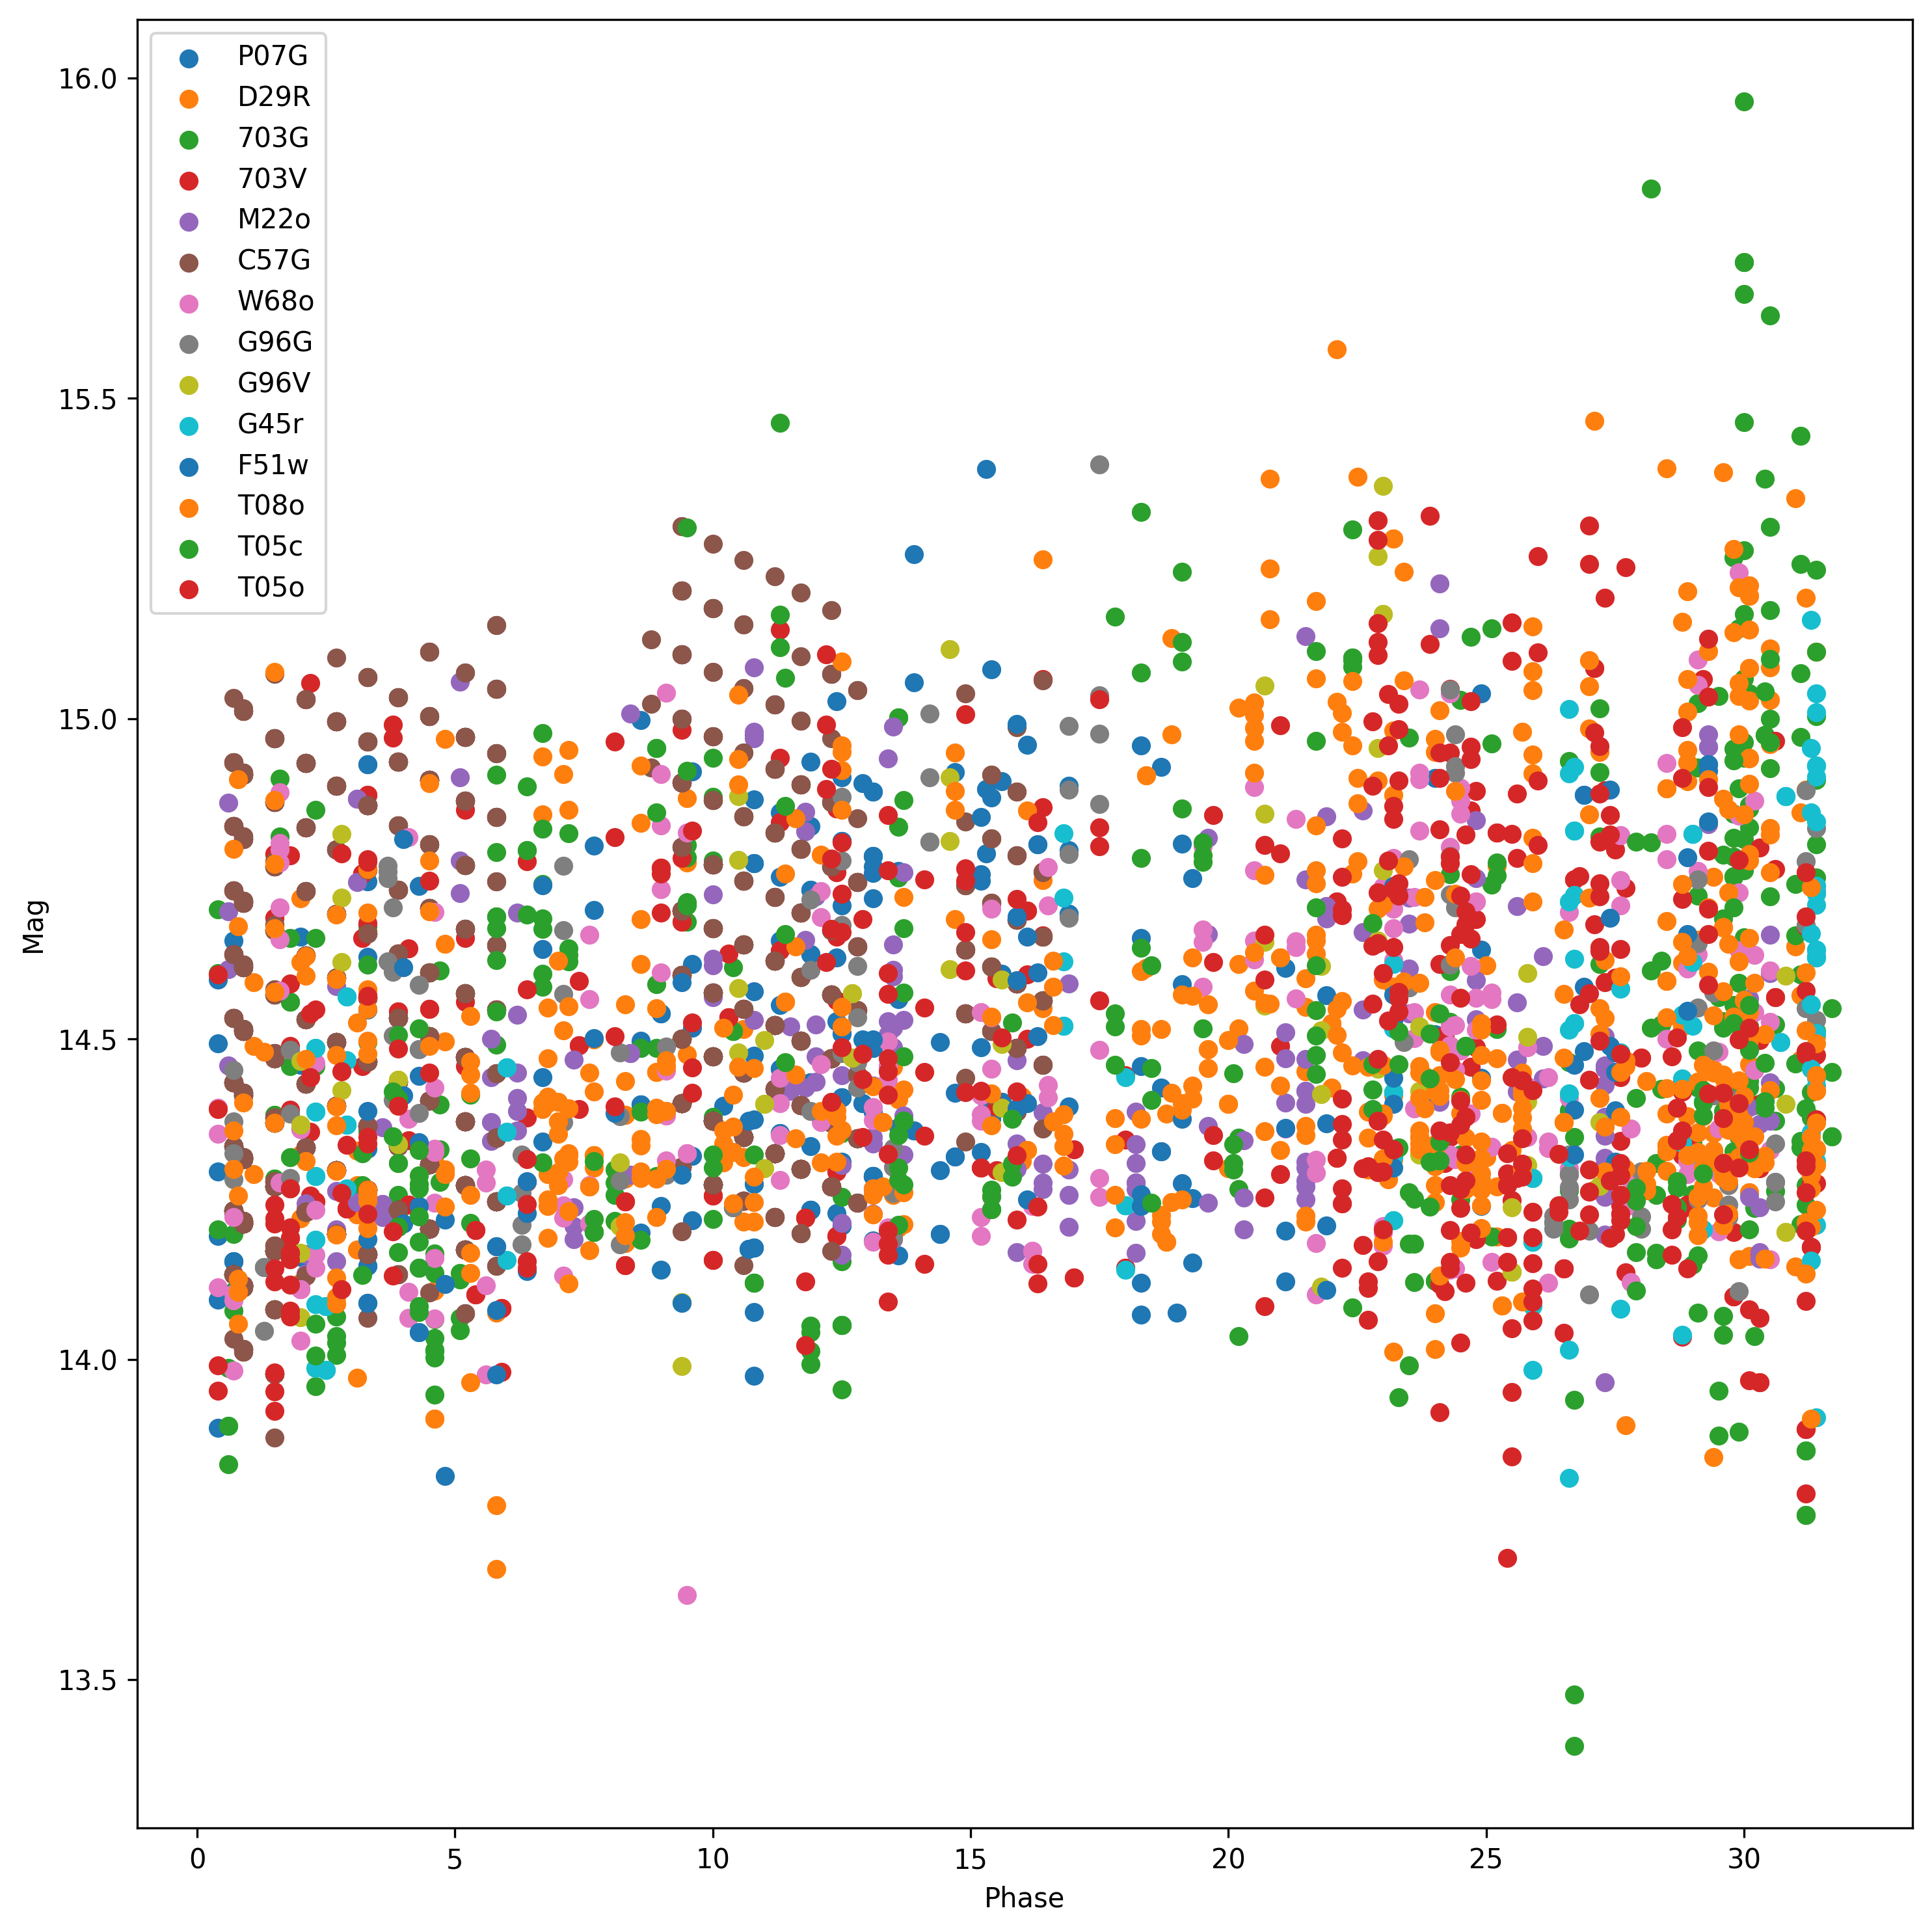

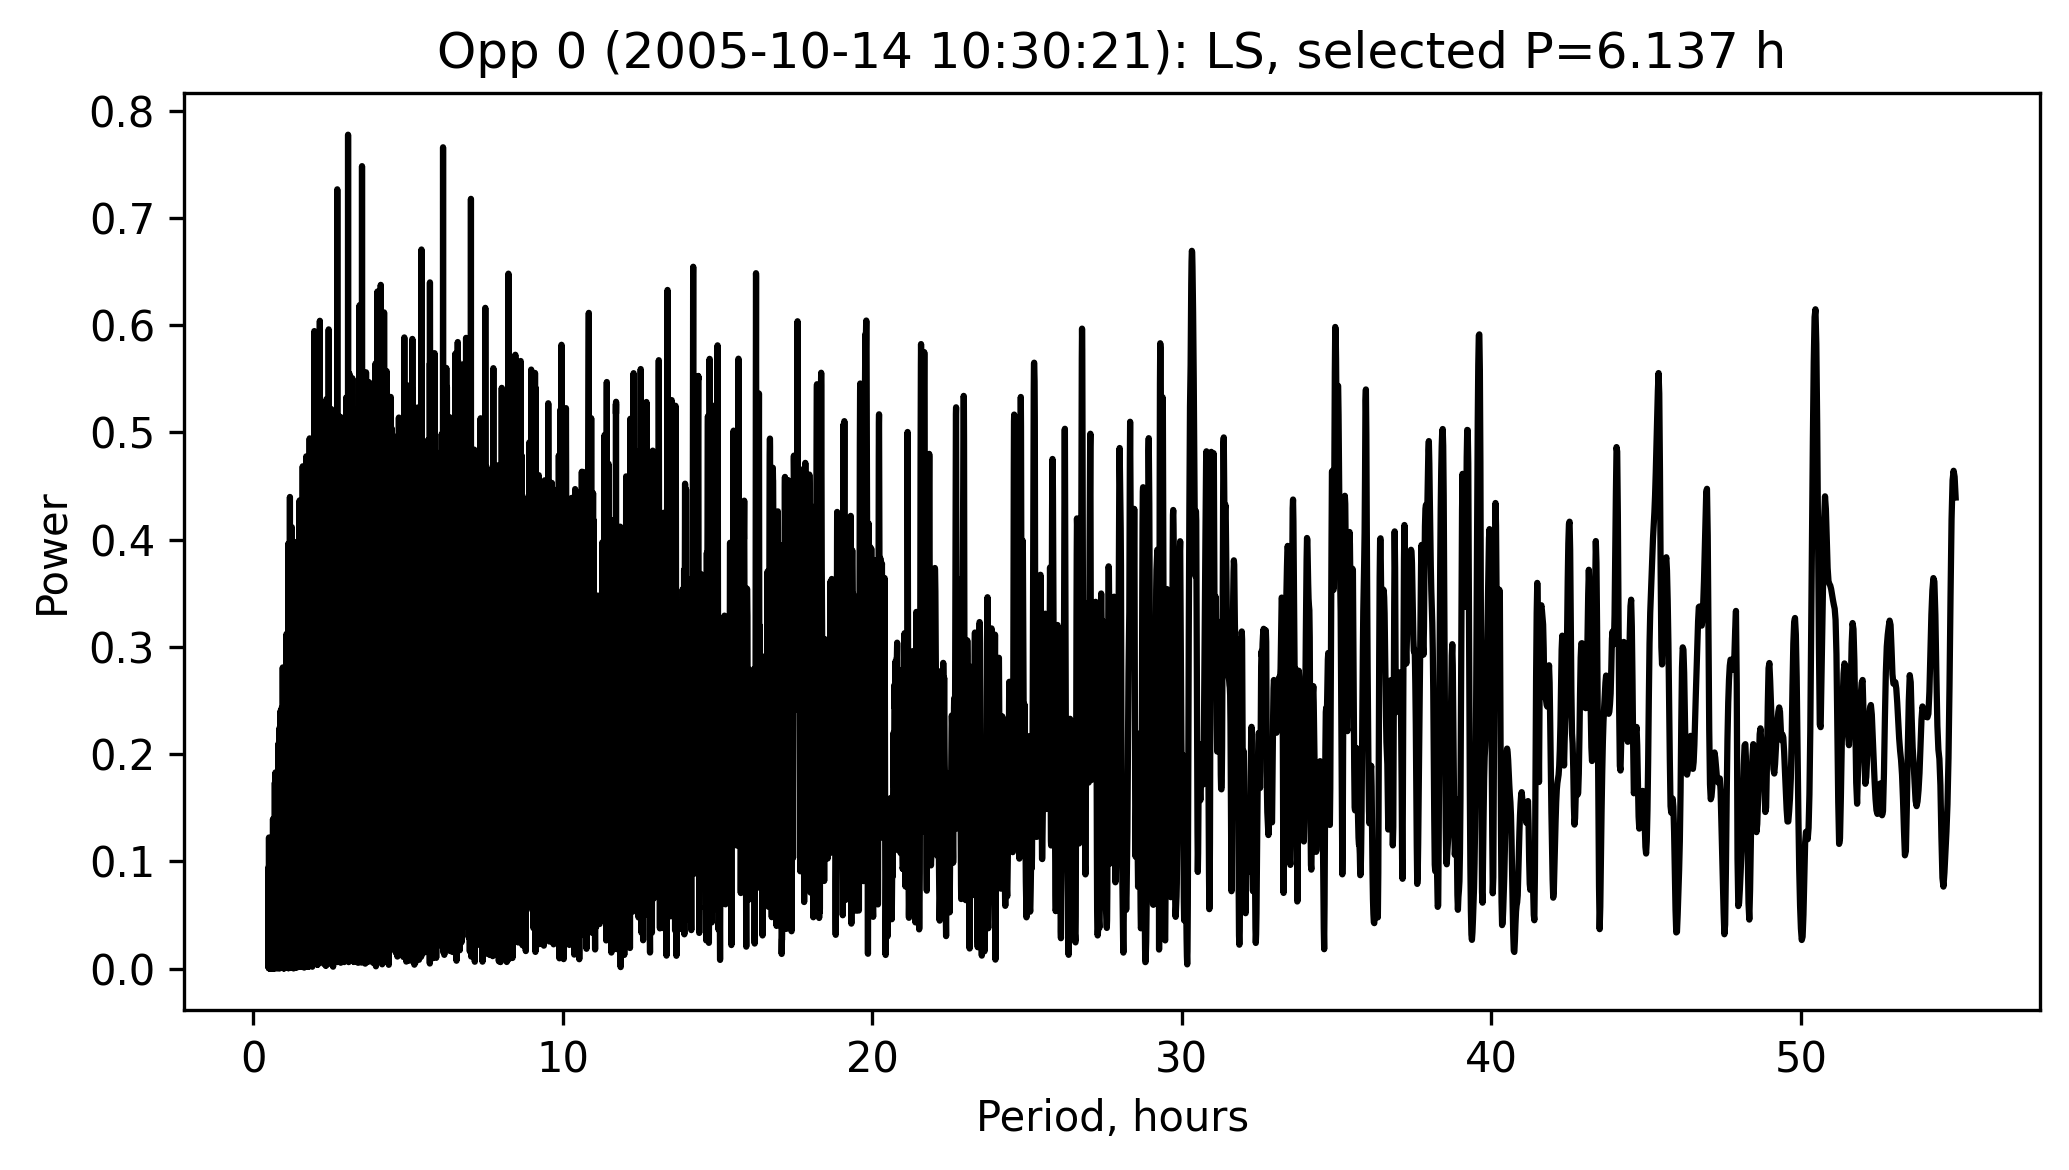

Opposition 5 (2013-02-16 10:30:21): top periods (hours)
     Period     power
0  4.060222  0.594664
1  4.060400  0.593330
2  3.068497  0.547293
3  3.068395  0.544054
4  3.068599  0.539225
Opposition 5: selected period = 4.0602 h; reason: top period kept (extrema count: n_max=2, n_min=2)


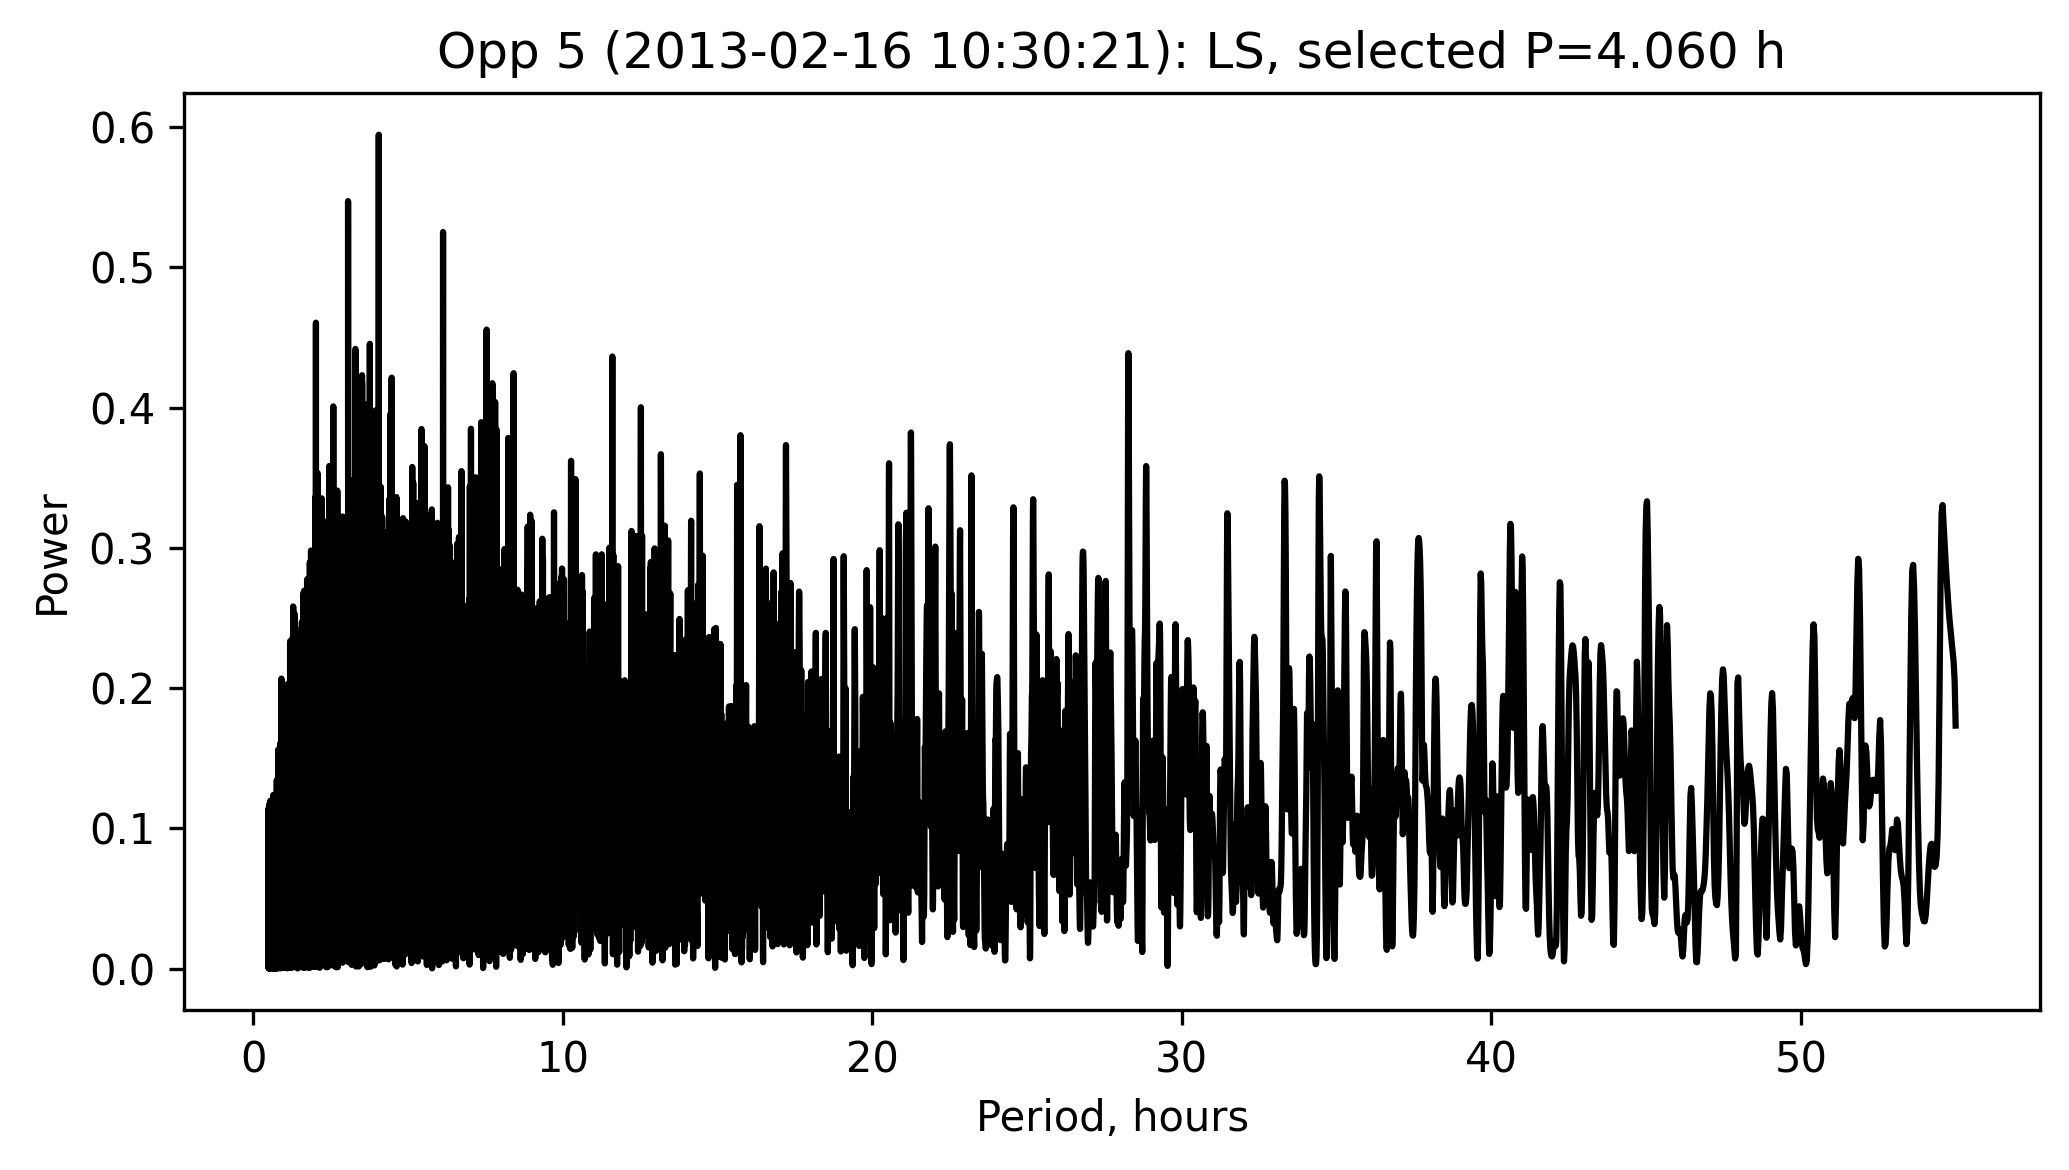

Opposition 7 (2016-01-12 10:30:21): top periods (hours)
     Period     power
0  3.068502  0.605052
1  3.068607  0.599420
2  3.068397  0.585790
3  6.136980  0.583069
4  3.068712  0.567230
Opposition 7: selected period = 6.1370 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=3.0685 h, P2=6.1370 h)


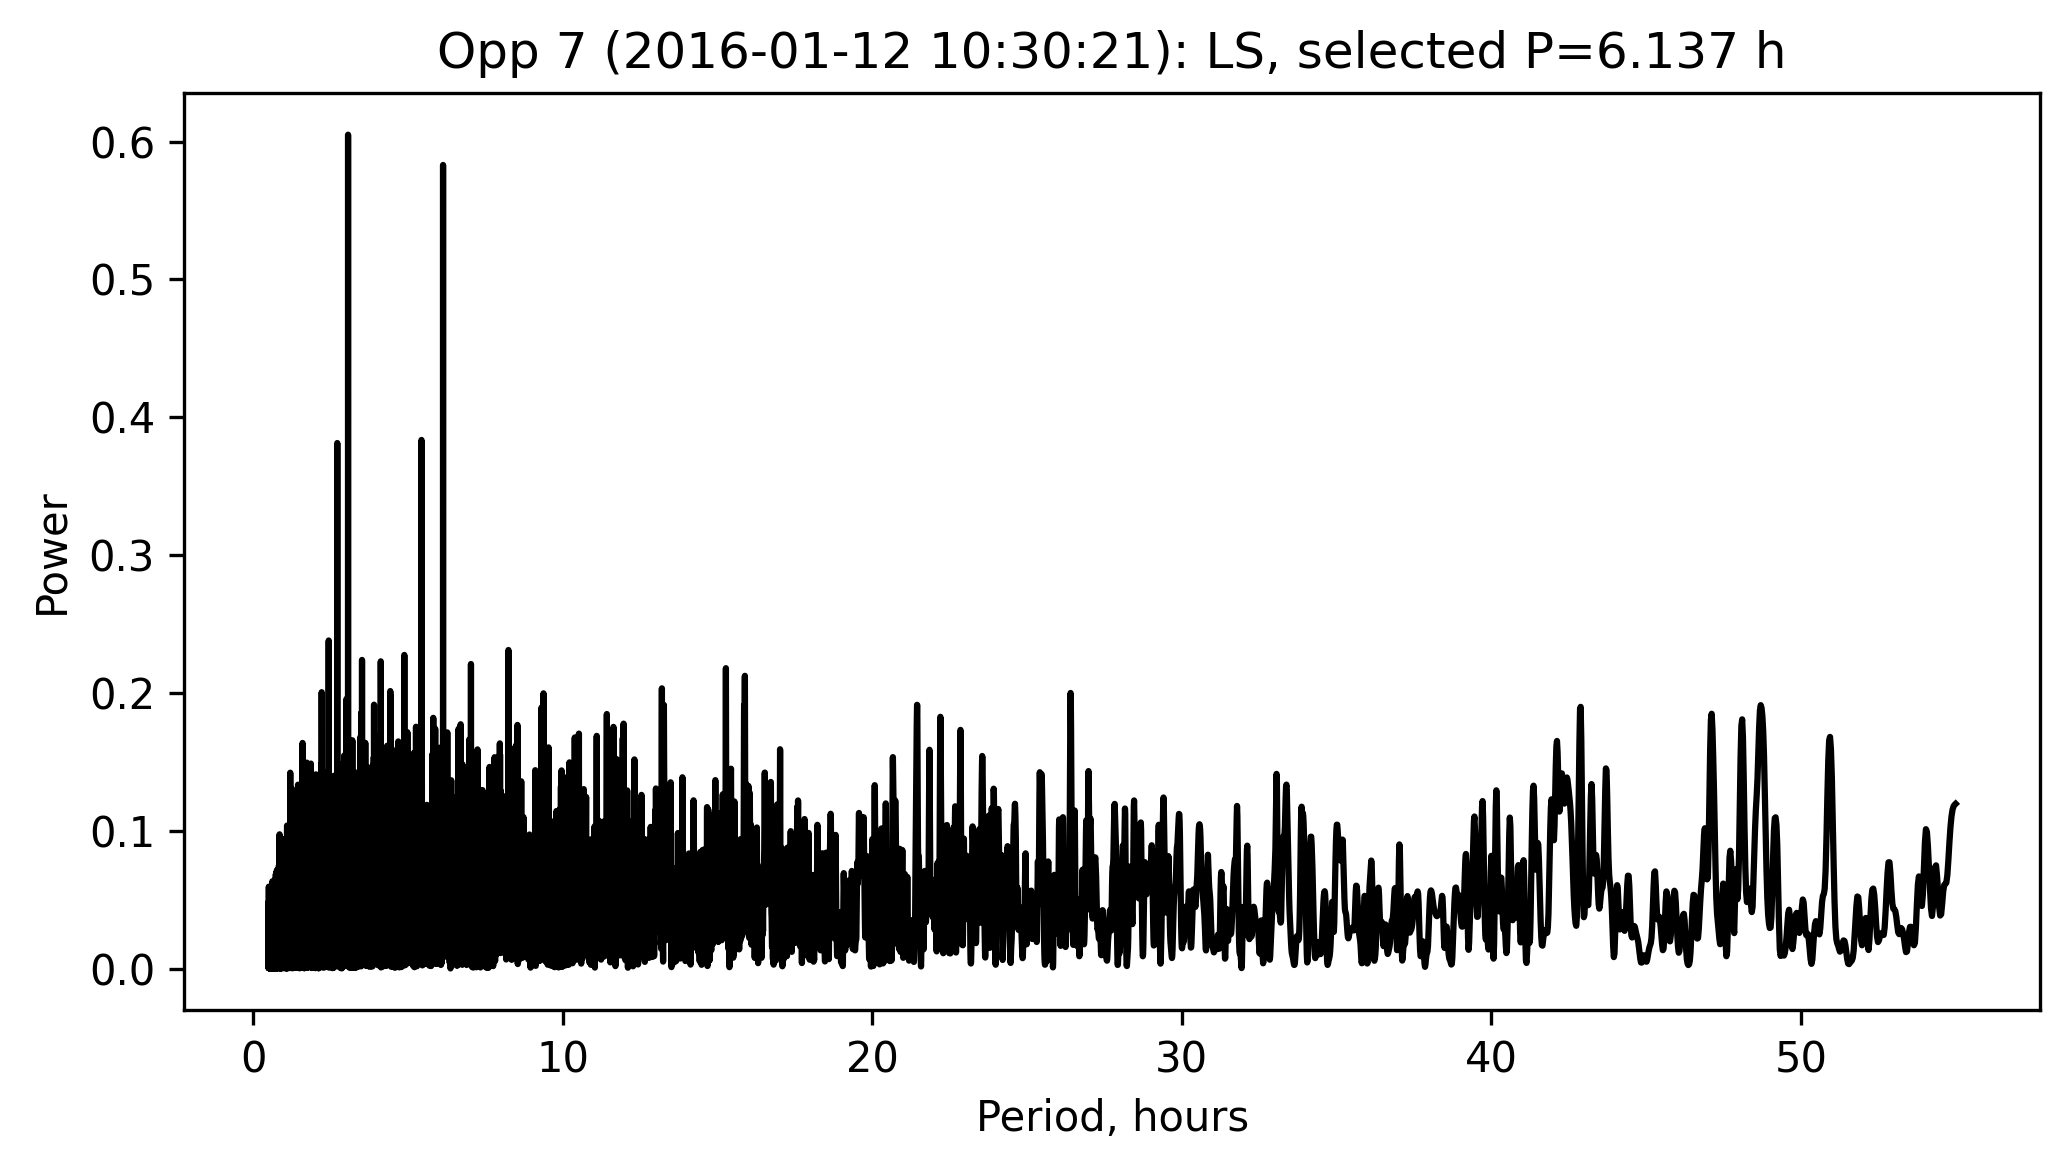

Opposition 9 (2018-11-29 10:30:21): top periods (hours)
     Period     power
0  3.068516  0.638527
1  3.068599  0.635029
2  3.068432  0.634602
3  3.068683  0.623732
4  3.068348  0.623445
Opposition 9: selected period = 6.1369 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=3.0685 h, P2=6.1369 h)


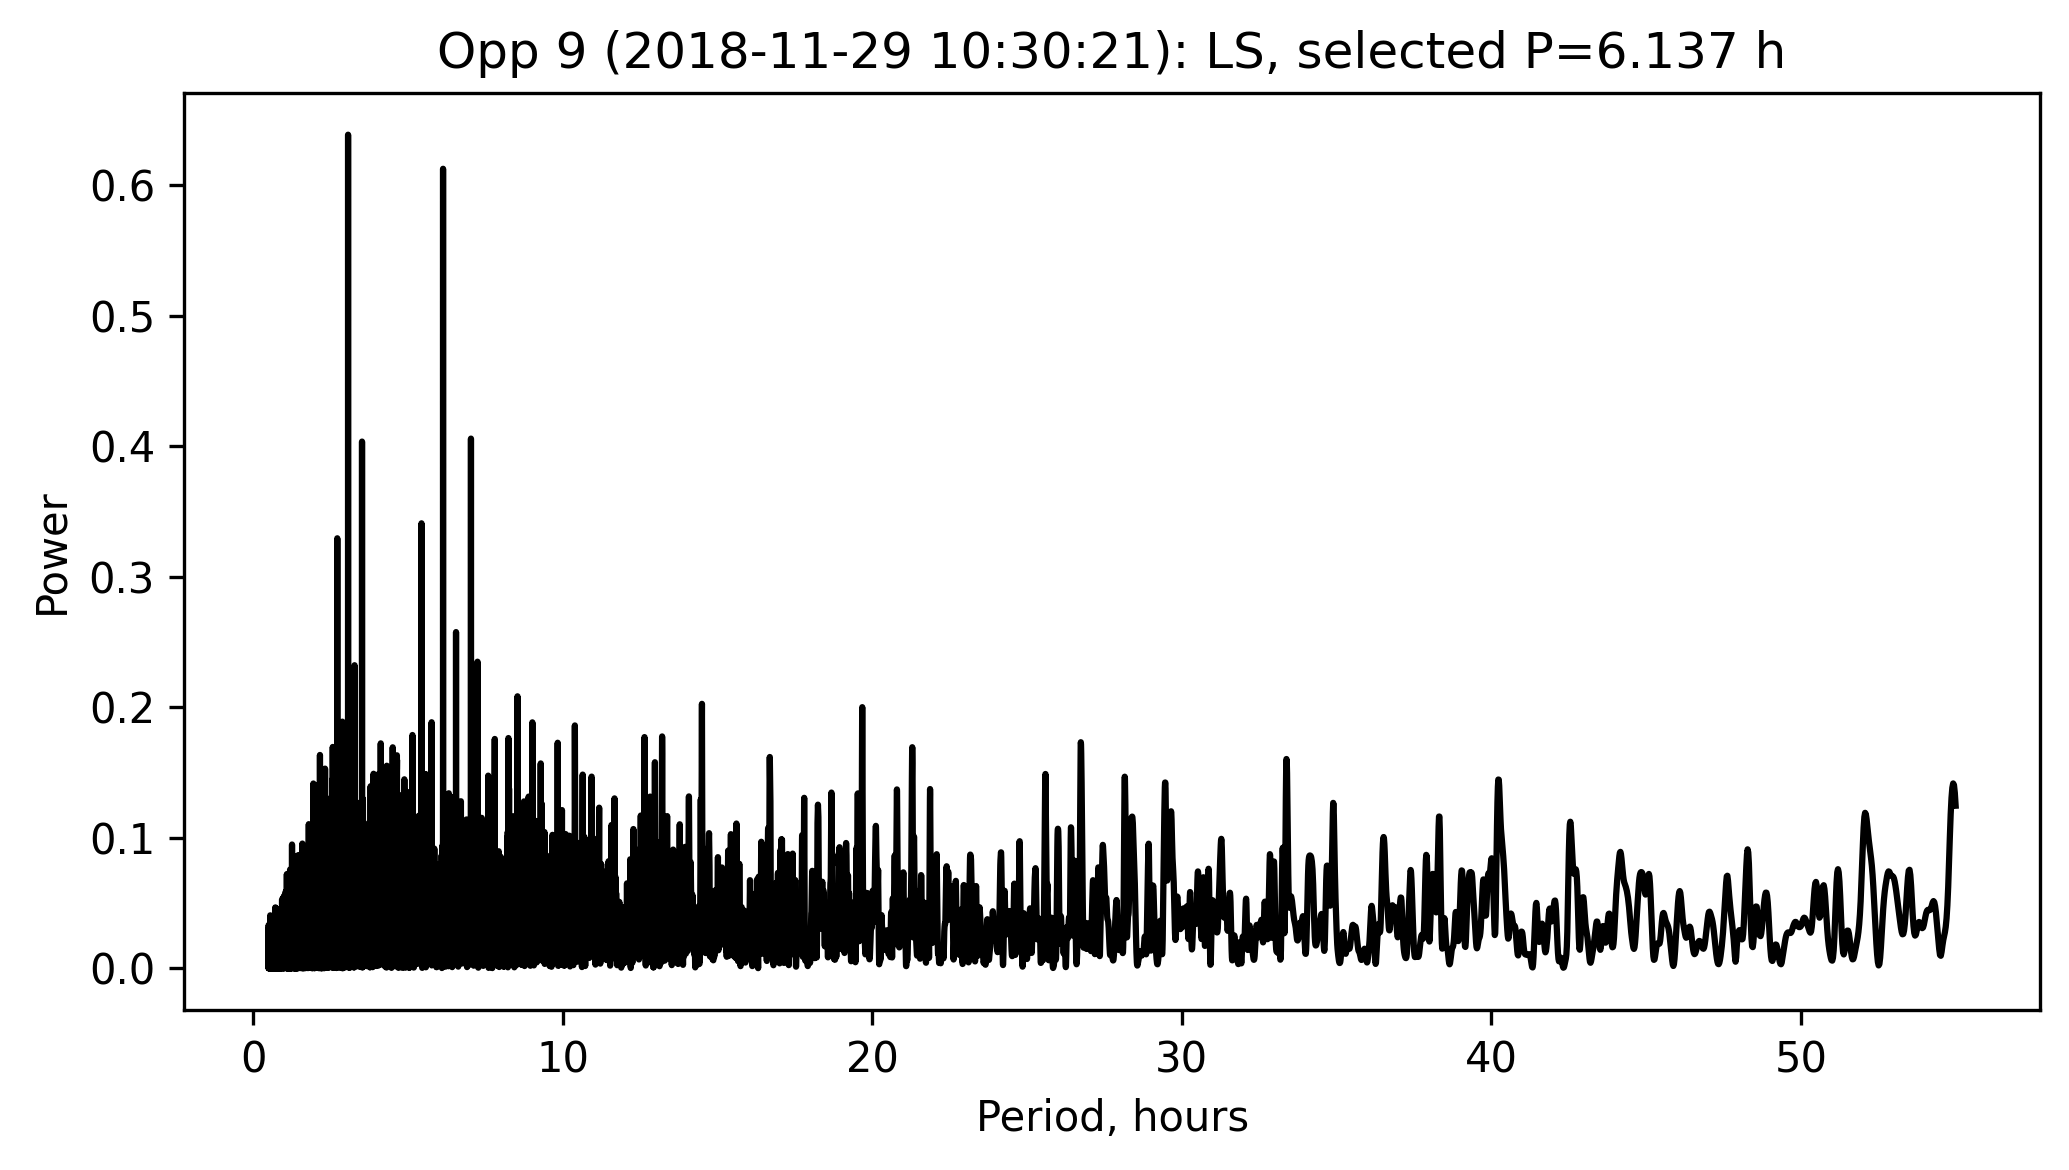

Opposition 10 (2020-05-04 10:30:21): top periods (hours)
     Period     power
0  3.068435  0.433437
1  3.068550  0.433039
2  3.068665  0.428609
3  3.068321  0.428467
4  3.068780  0.420898
Opposition 10: selected period = 6.1371 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=3.0684 h, P2=6.1371 h)


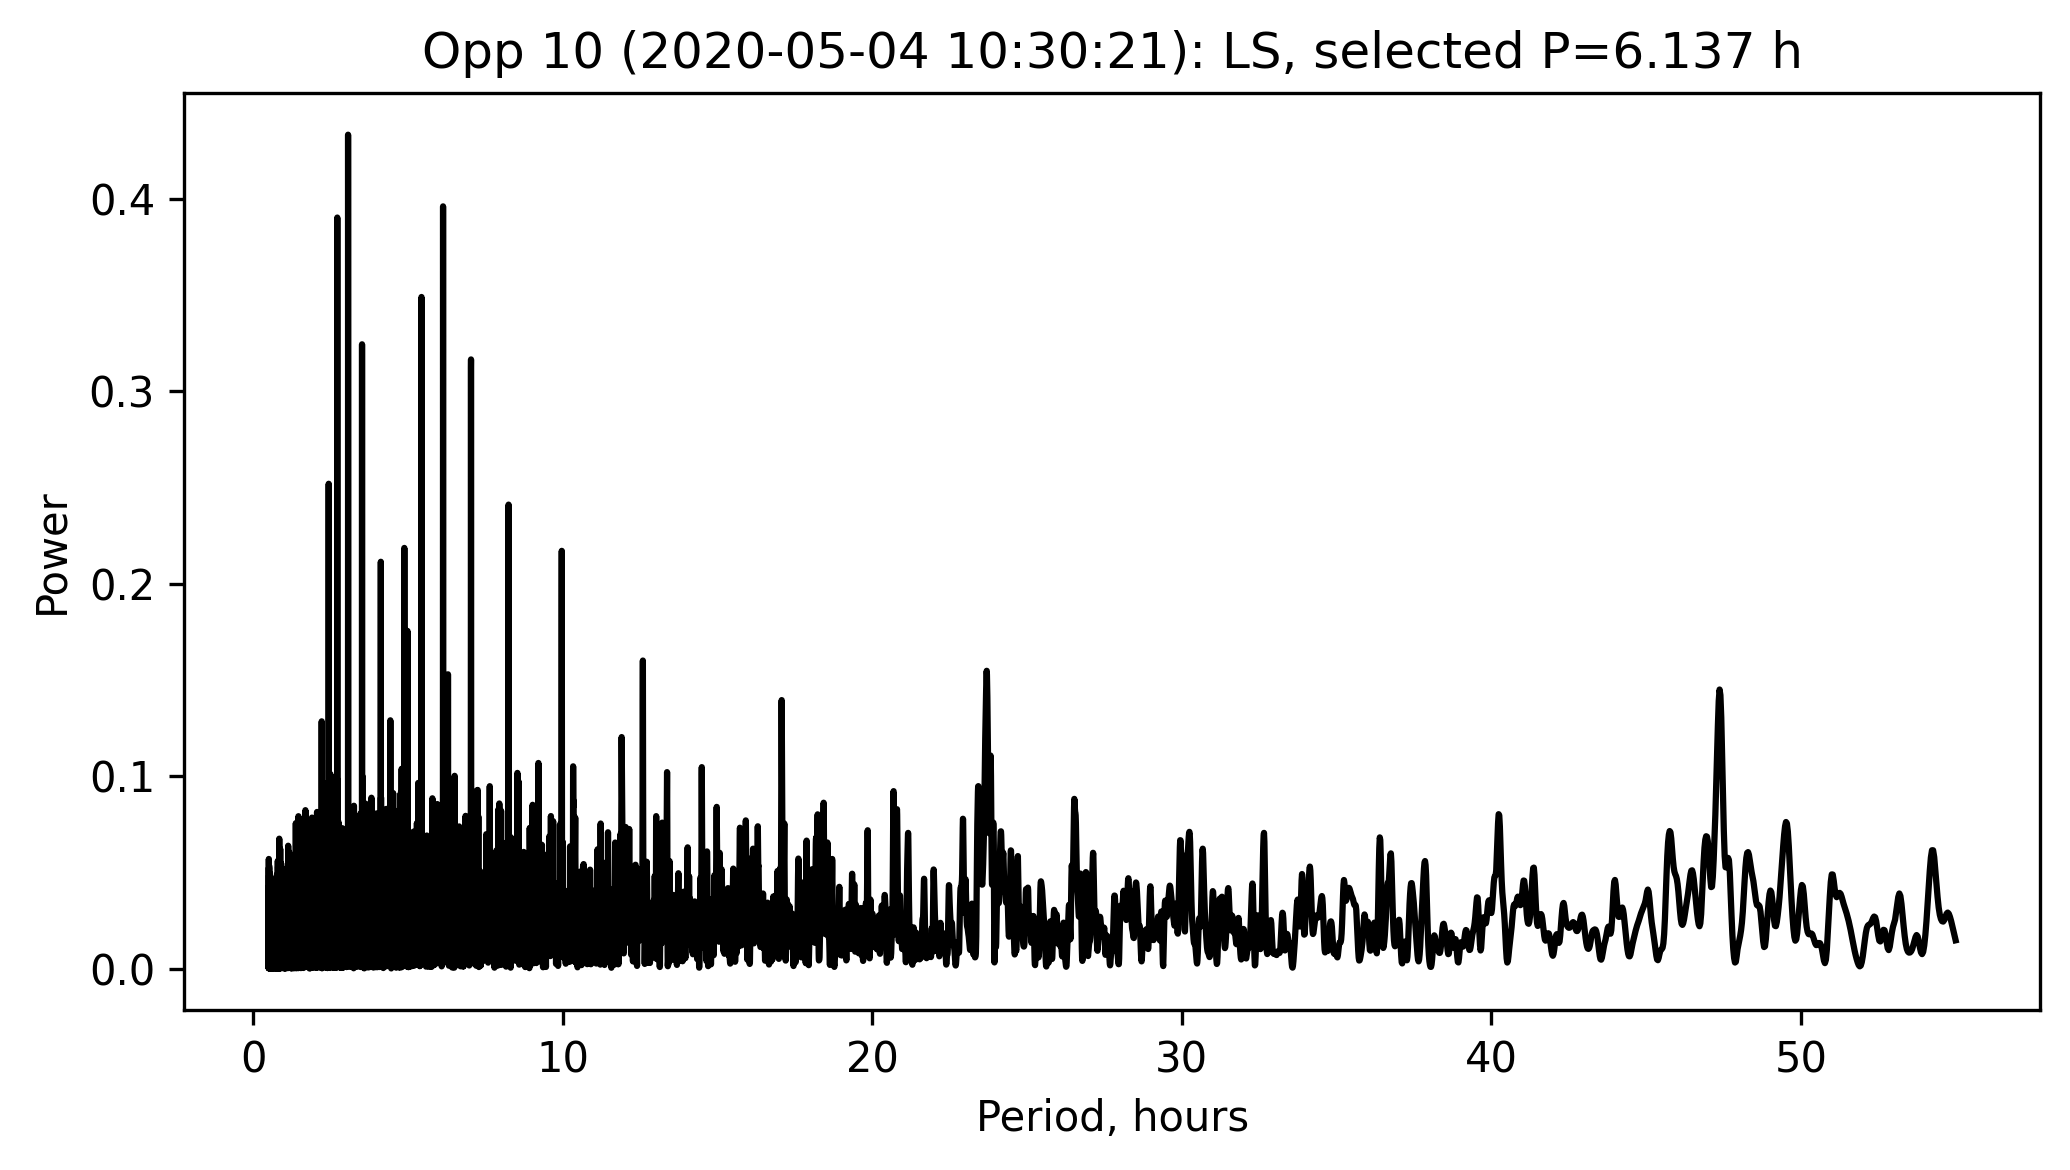

Opposition 11 (2021-10-11 10:30:21): top periods (hours)
     Period     power
0  3.068261  0.710674
1  3.068184  0.709926
2  3.068337  0.709334
3  3.068108  0.706875
4  3.068413  0.706191
Opposition 11: selected period = 6.1365 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=3.0683 h, P2=6.1365 h)


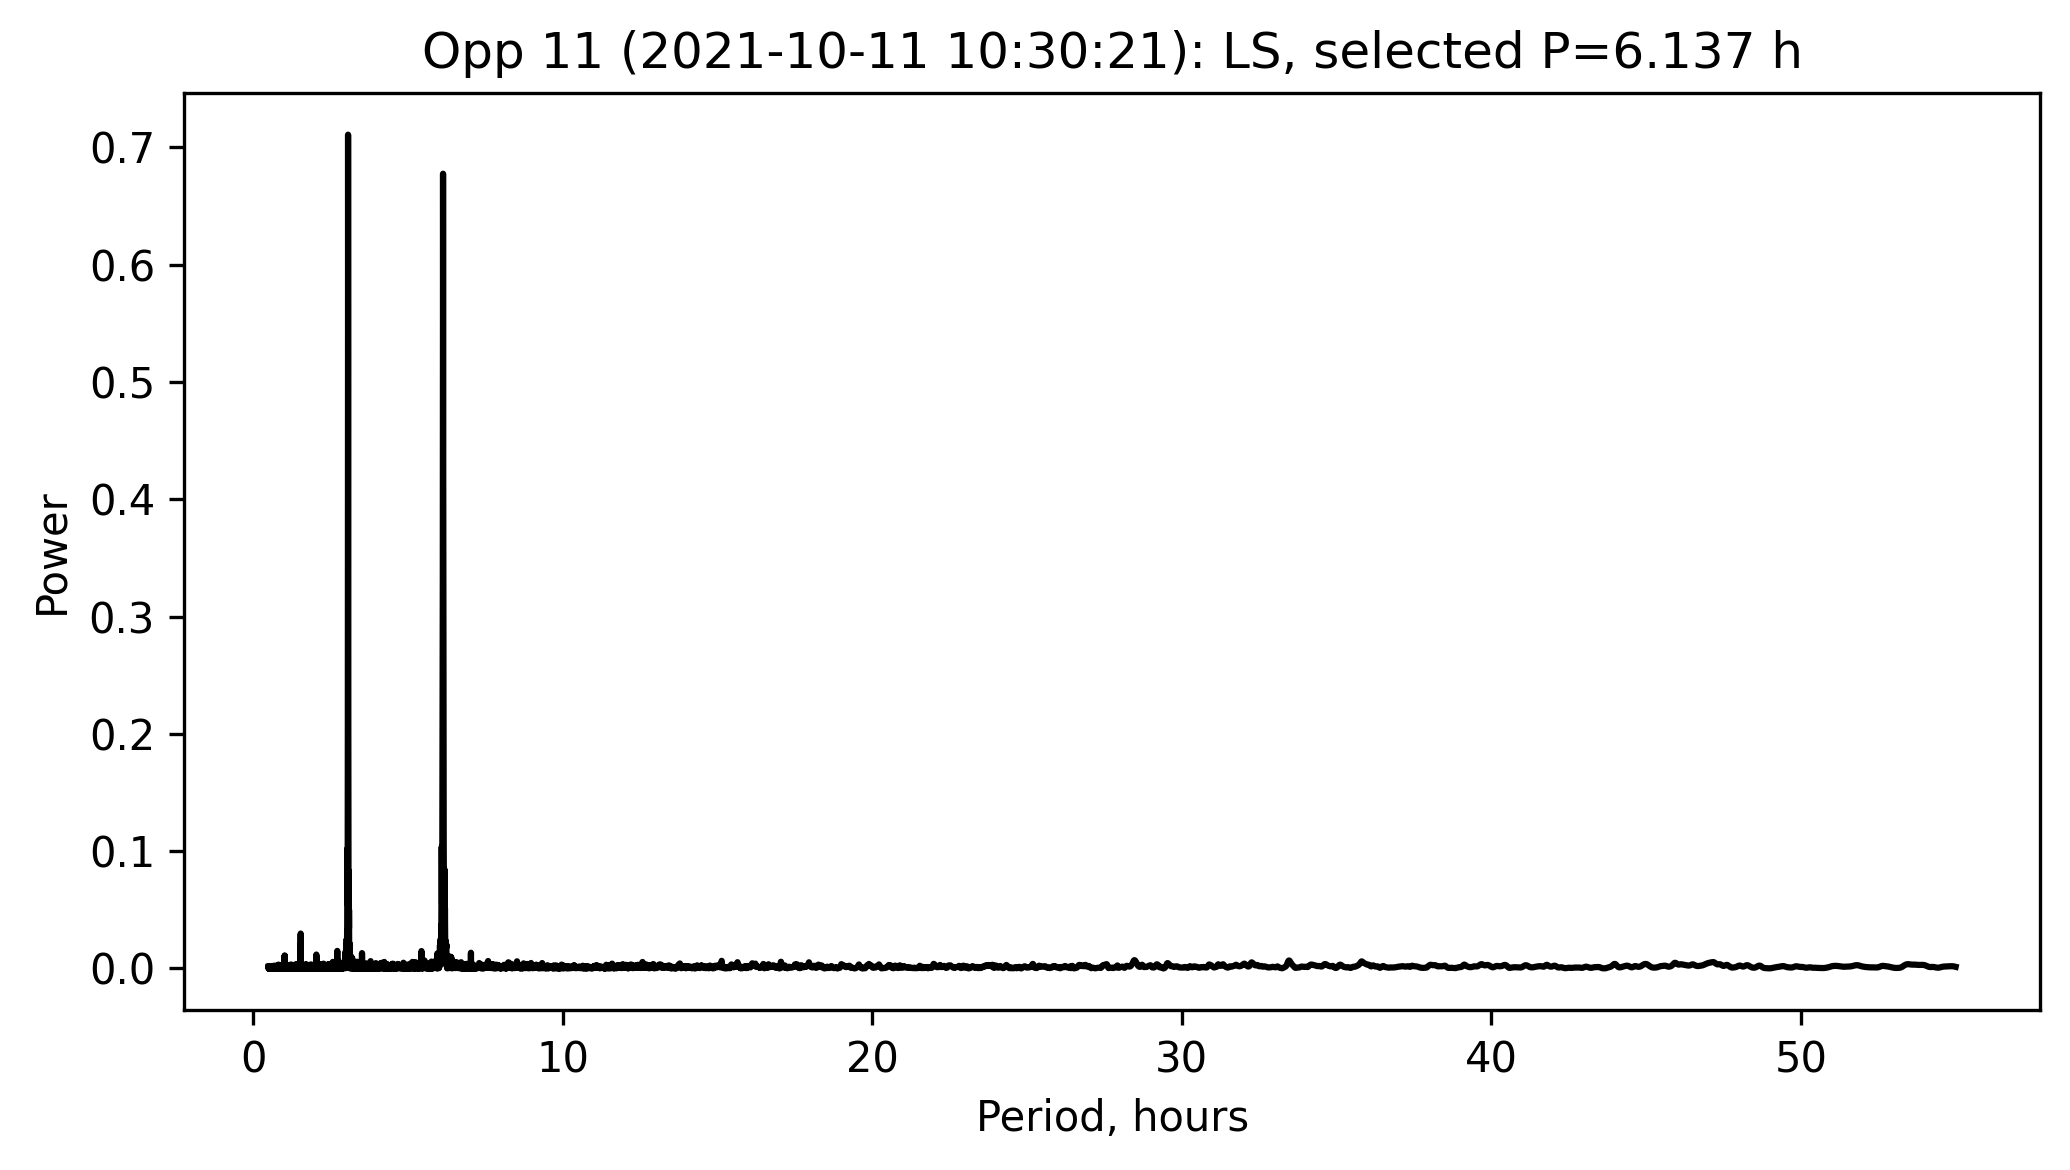

Opposition 12 (2023-04-10 10:30:21): top periods (hours)
     Period     power
0  3.068304  0.618106
1  3.068404  0.613647
2  3.068203  0.612636
3  3.068505  0.599027
4  3.068102  0.598578
Opposition 12: selected period = 6.1365 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=3.0683 h, P2=6.1365 h)


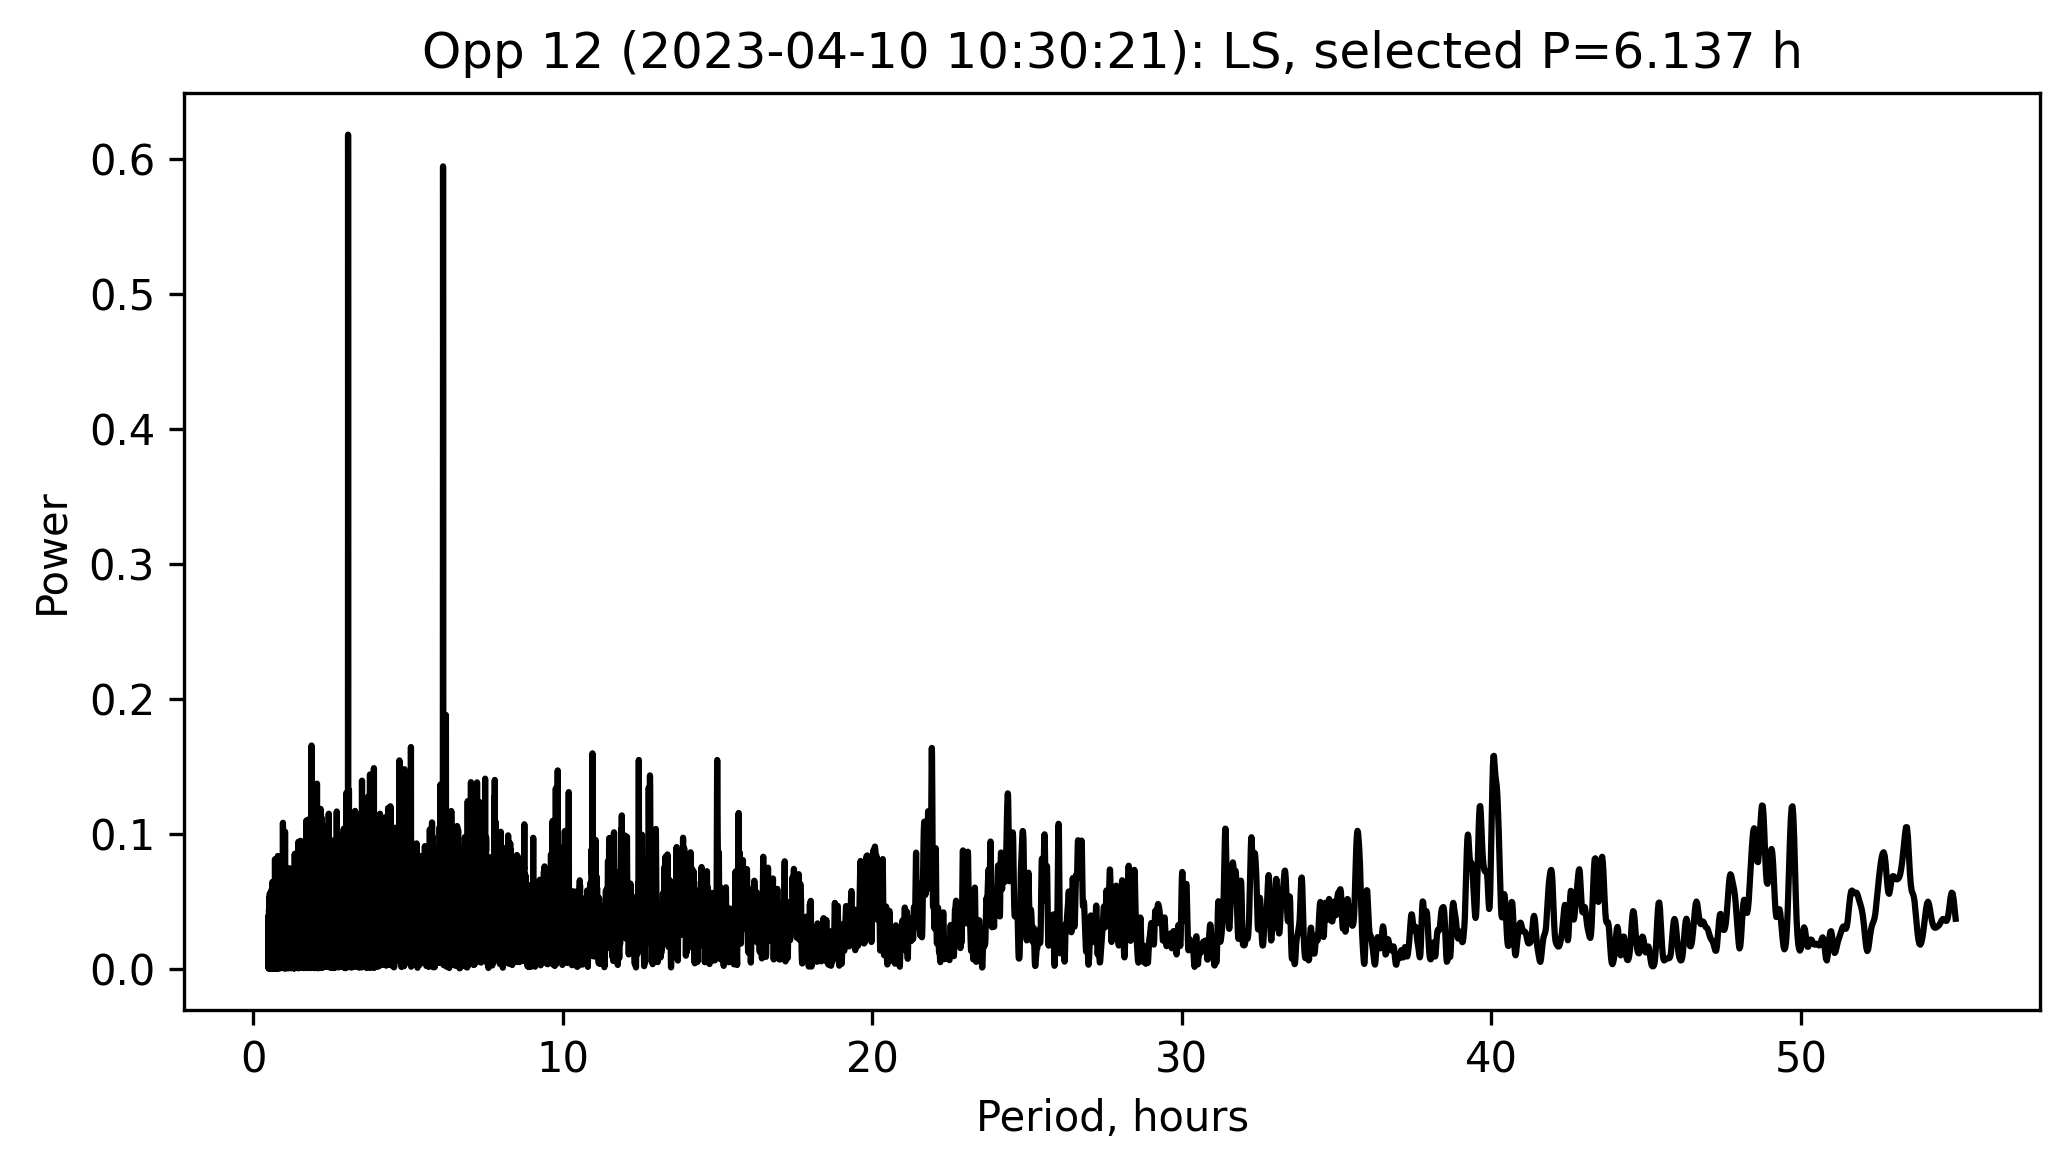

Opposition 13 (2024-08-27 10:30:21): top periods (hours)
     Period     power
0  3.068508  0.698844
1  3.068417  0.695369
2  3.068598  0.687913
3  3.068326  0.677168
4  6.136849  0.668620
Opposition 13: selected period = 6.1368 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=3.0685 h, P2=6.1368 h)


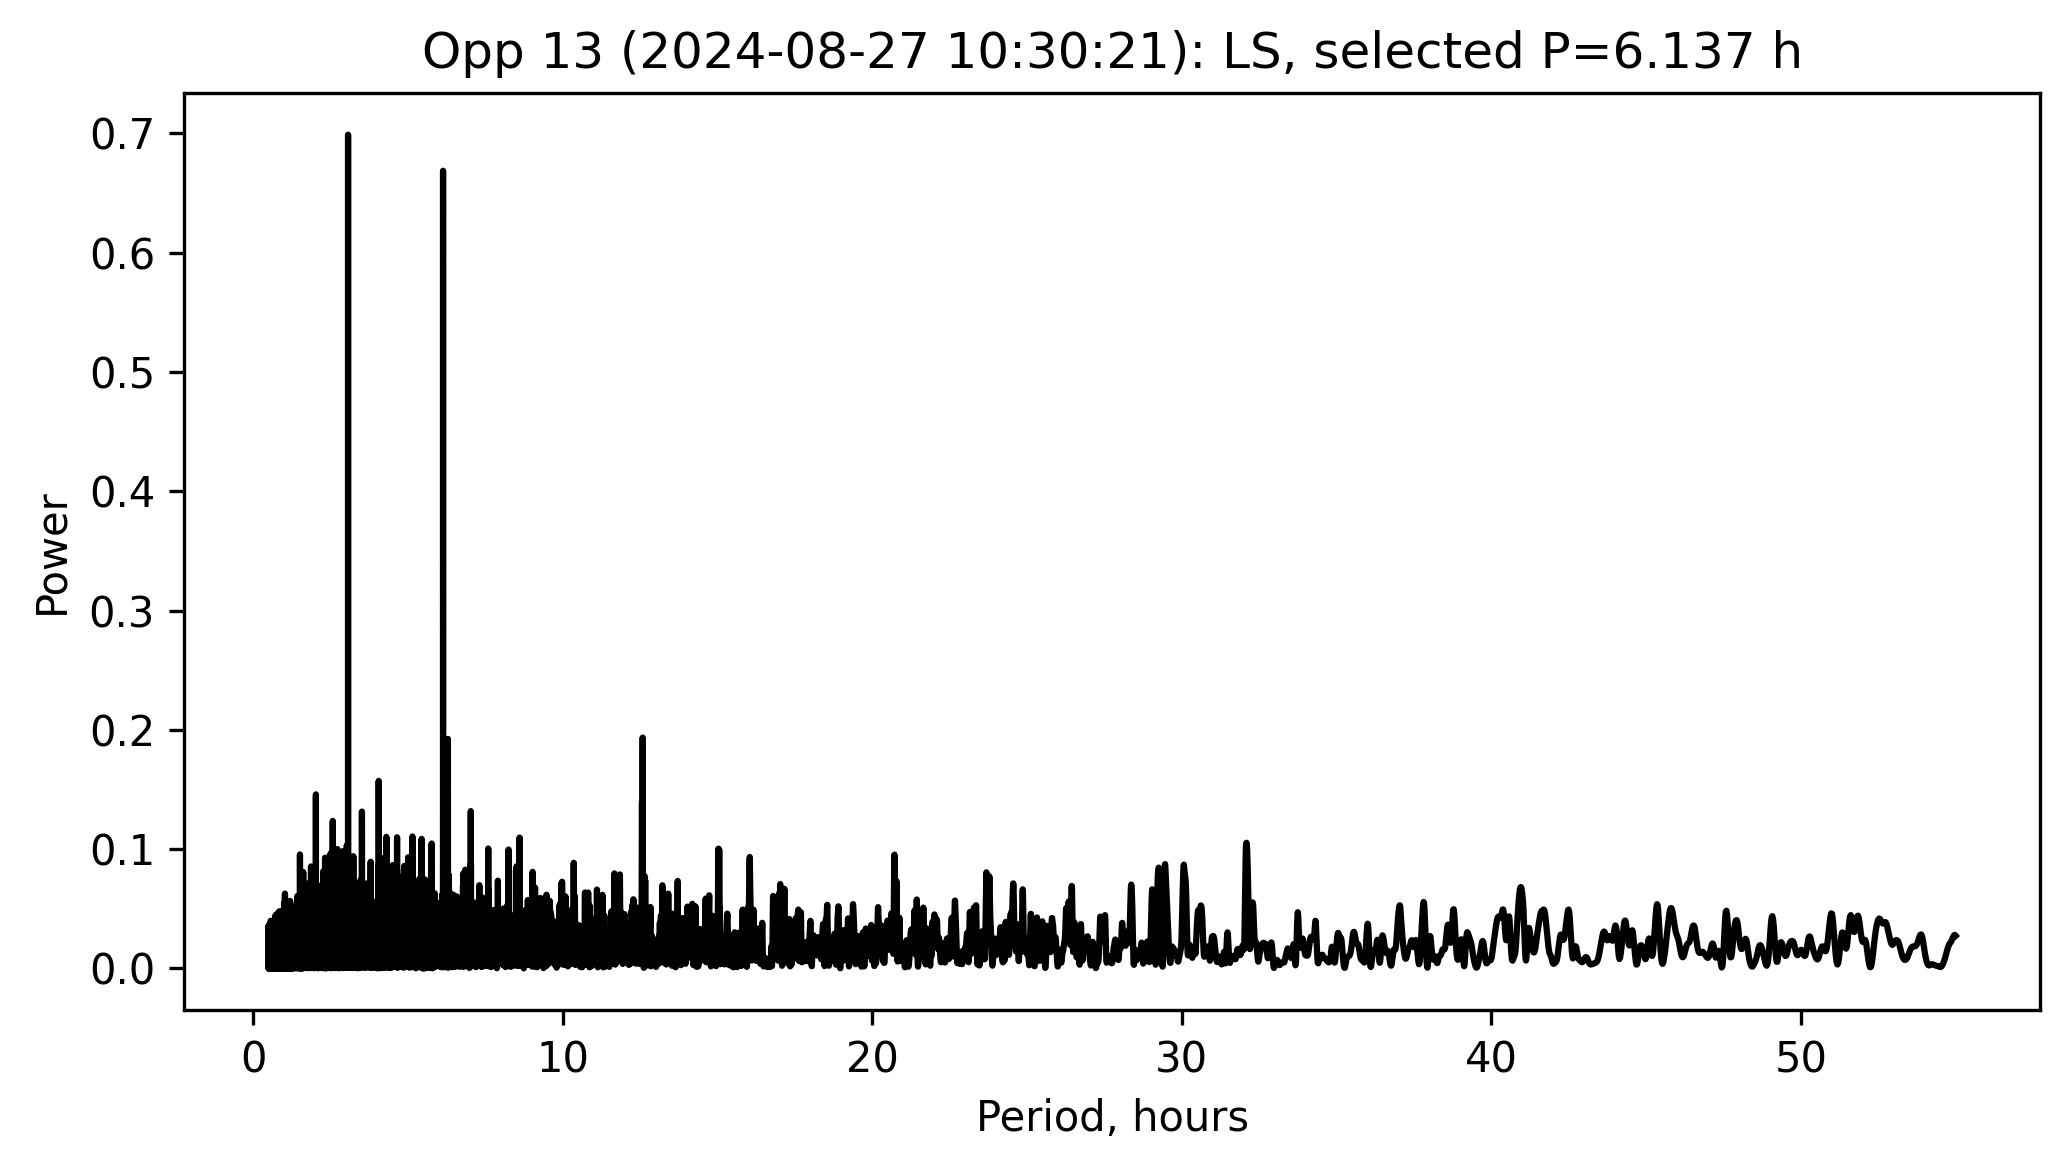

c:\Users\kn18001\Documents\Asteroids\Combined-dataset-period-analysis\asteroid_ls.py:591: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=1)


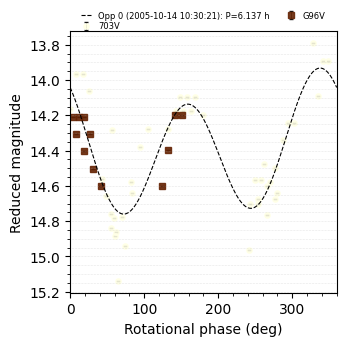

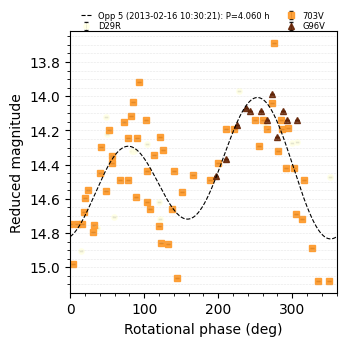

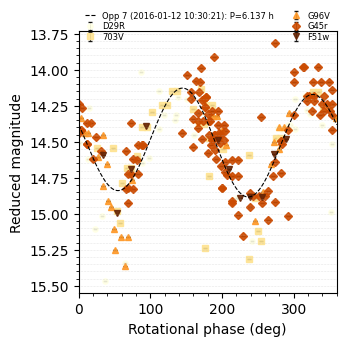

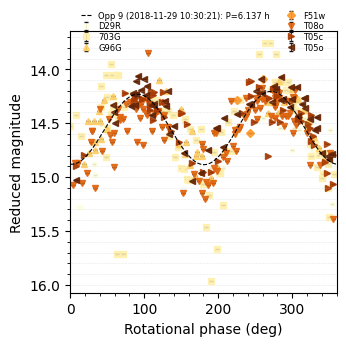

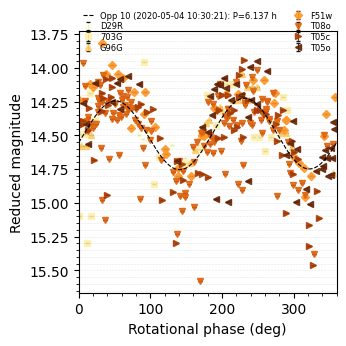

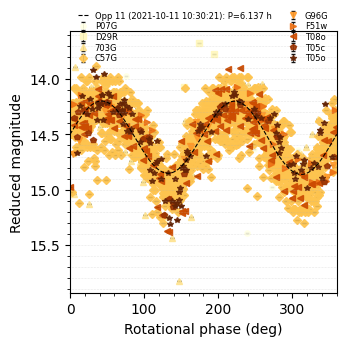

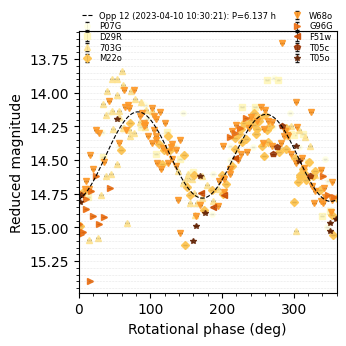

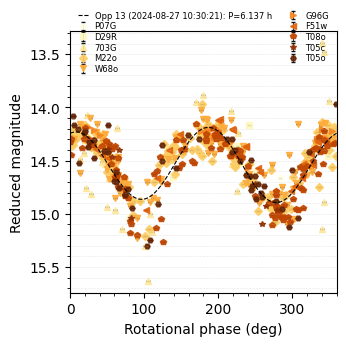

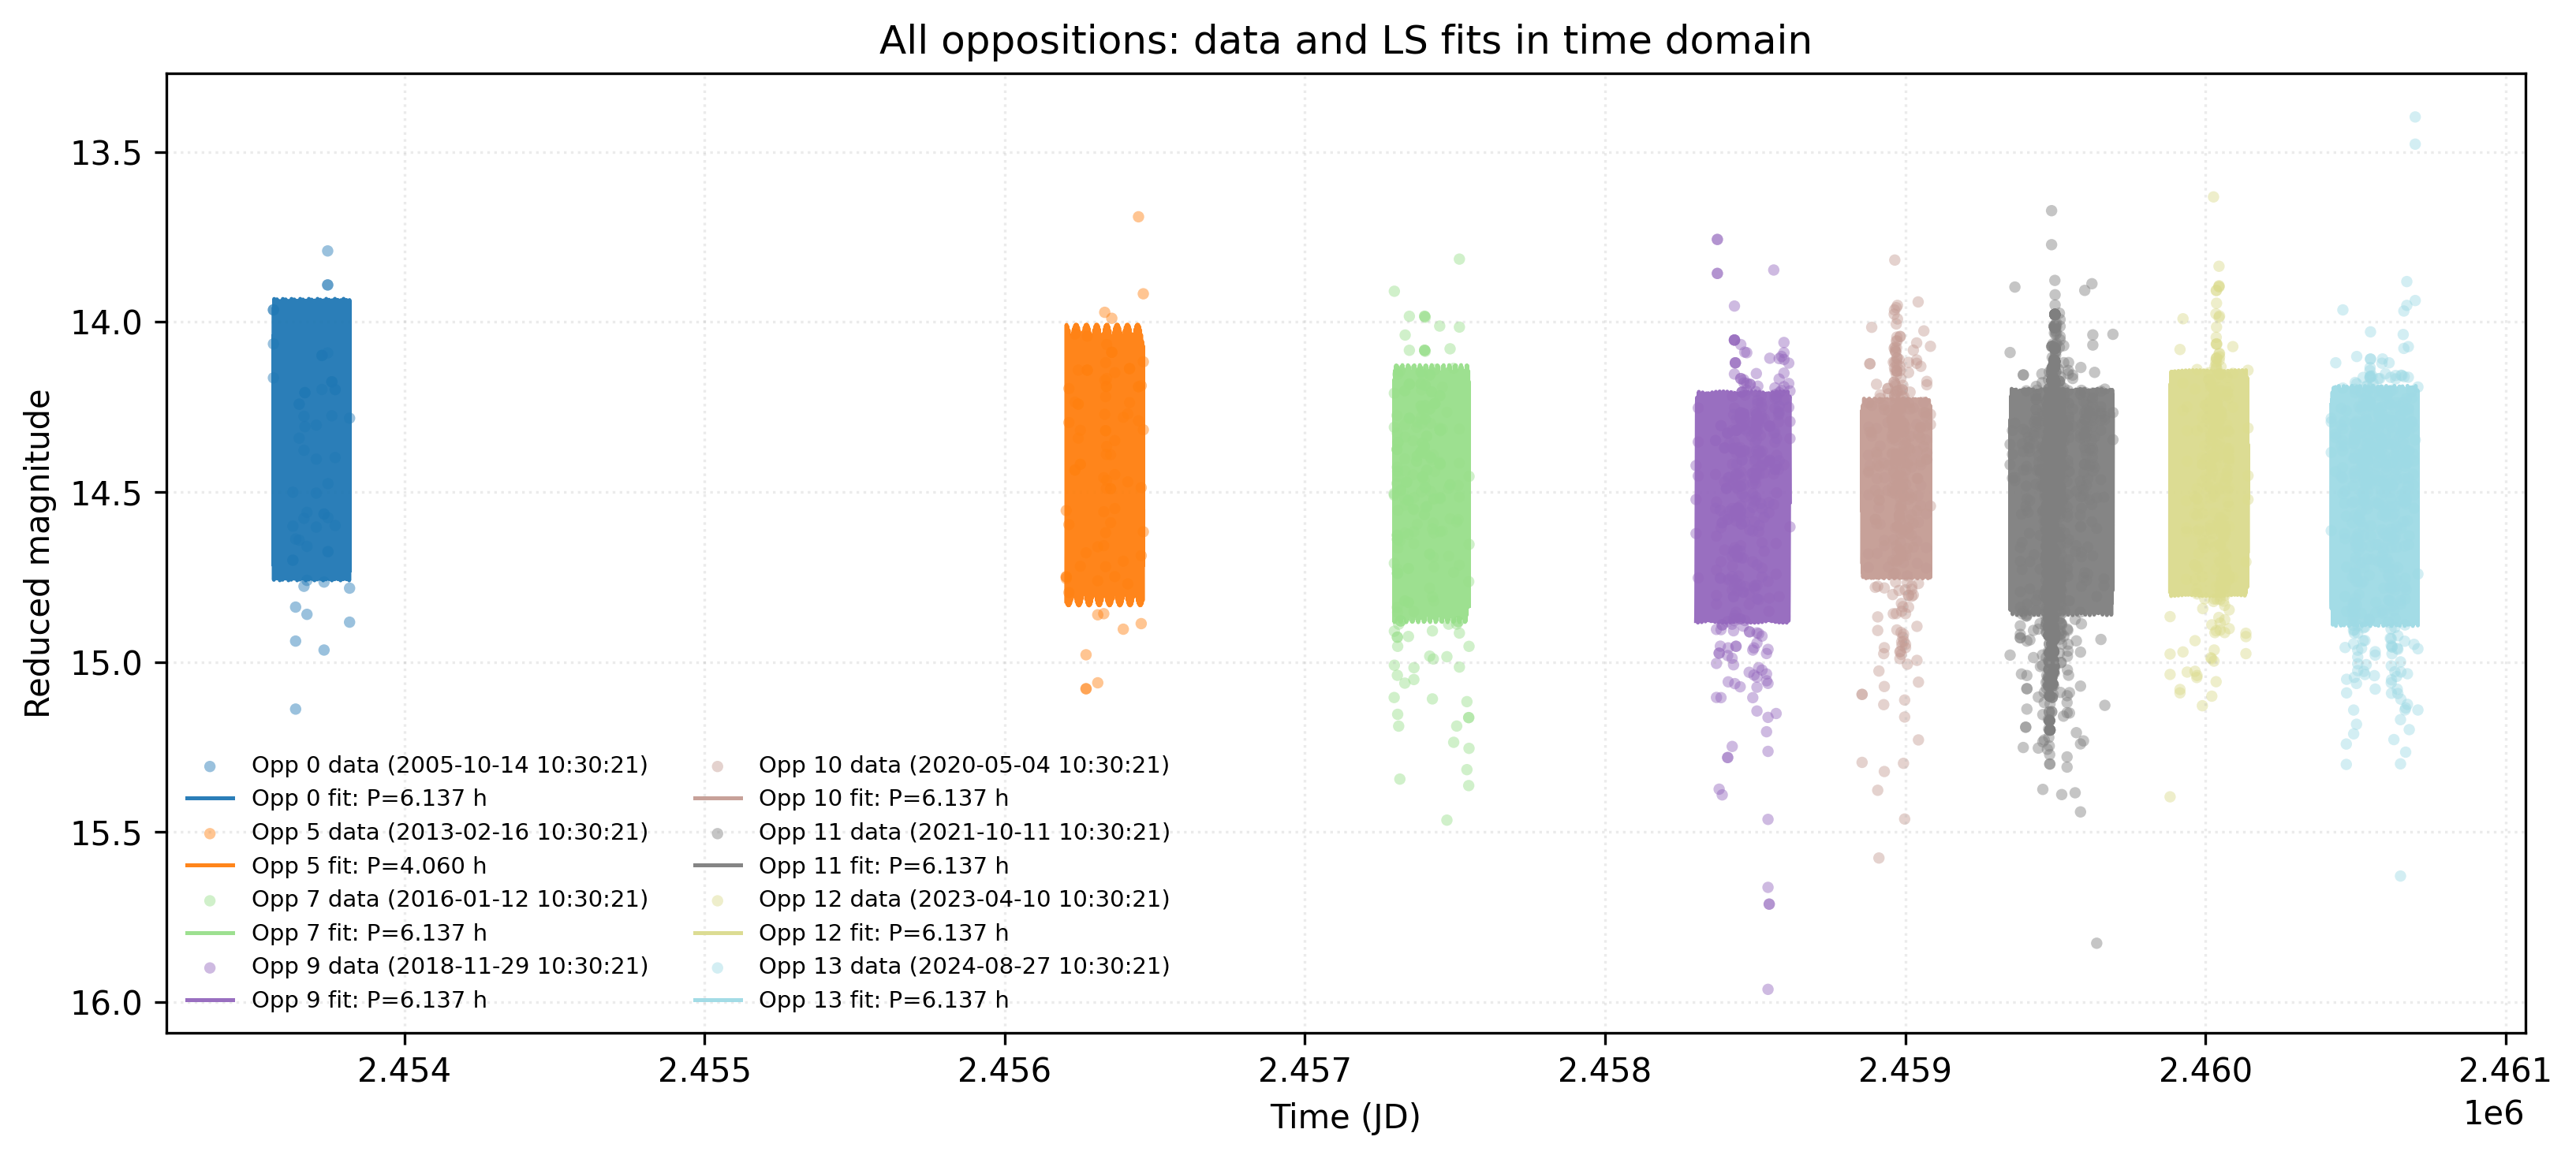

In [7]:
path_of_dict = r"../Asteroid_data/Plots_and_data/4303_data_compile_fix_G1G2.pkl"
with open(path_of_dict, 'rb') as file:
        # Load the data from the file
        dict_sheets = pickle.load(file)


pipe = AsteroidLSPipeline(dict_sheets, Asteroid_number=4303)

opp_data = pipe.reading_data(
    split_oppositions=True,
    opposition_method="horizons",
    min_obs_per_opposition=50,
)

opp_ls = pipe.LS_initiate_per_opposition(
    opposition_data=opp_data,
    nterms=2,
    peak_idx=0,
    minf=1 / (55 / 24),
    double_period_tol=0.12,
)

pipe.visualize_ls_per_opposition(opp_ls)
pipe.visualize_time_series_all_oppositions(opp_ls)


703V
M22o
T05c
T05o
G96G
G45r
F51w
I41r
T08o1
W68o
Detected opposition epochs from Horizons:
  Opp 0: JD=2453922.684, UTC=2006-07-06 04:25:10, elong=174.37 deg
  Opp 1: JD=2454463.684, UTC=2007-12-29 04:25:10, elong=175.15 deg
  Opp 2: JD=2454975.684, UTC=2009-05-24 04:25:10, elong=177.21 deg
  Opp 3: JD=2457562.684, UTC=2016-06-23 04:25:10, elong=176.62 deg
  Opp 4: JD=2458095.684, UTC=2017-12-08 04:25:10, elong=179.64 deg
  Opp 5: JD=2458615.684, UTC=2019-05-12 04:25:10, elong=175.01 deg
  Opp 6: JD=2460153.684, UTC=2023-07-28 04:25:10, elong=170.80 deg
Opposition 0: date=2006-07-06 04:25:10, total observations=8
Opposition 0: discarded (n=8 < 50)
Opposition 1: date=2007-12-29 04:25:10, total observations=11
Opposition 1: discarded (n=11 < 50)
Opposition 2: date=2009-05-24 04:25:10, total observations=99
Opposition 2 (2009-05-24 04:25:10): 99 points, kept 99 after outlier filtering
Opposition 3: date=2016-06-23 04:25:10, total observations=233
Opposition 3 (2016-06-23 04:25:10): 233 

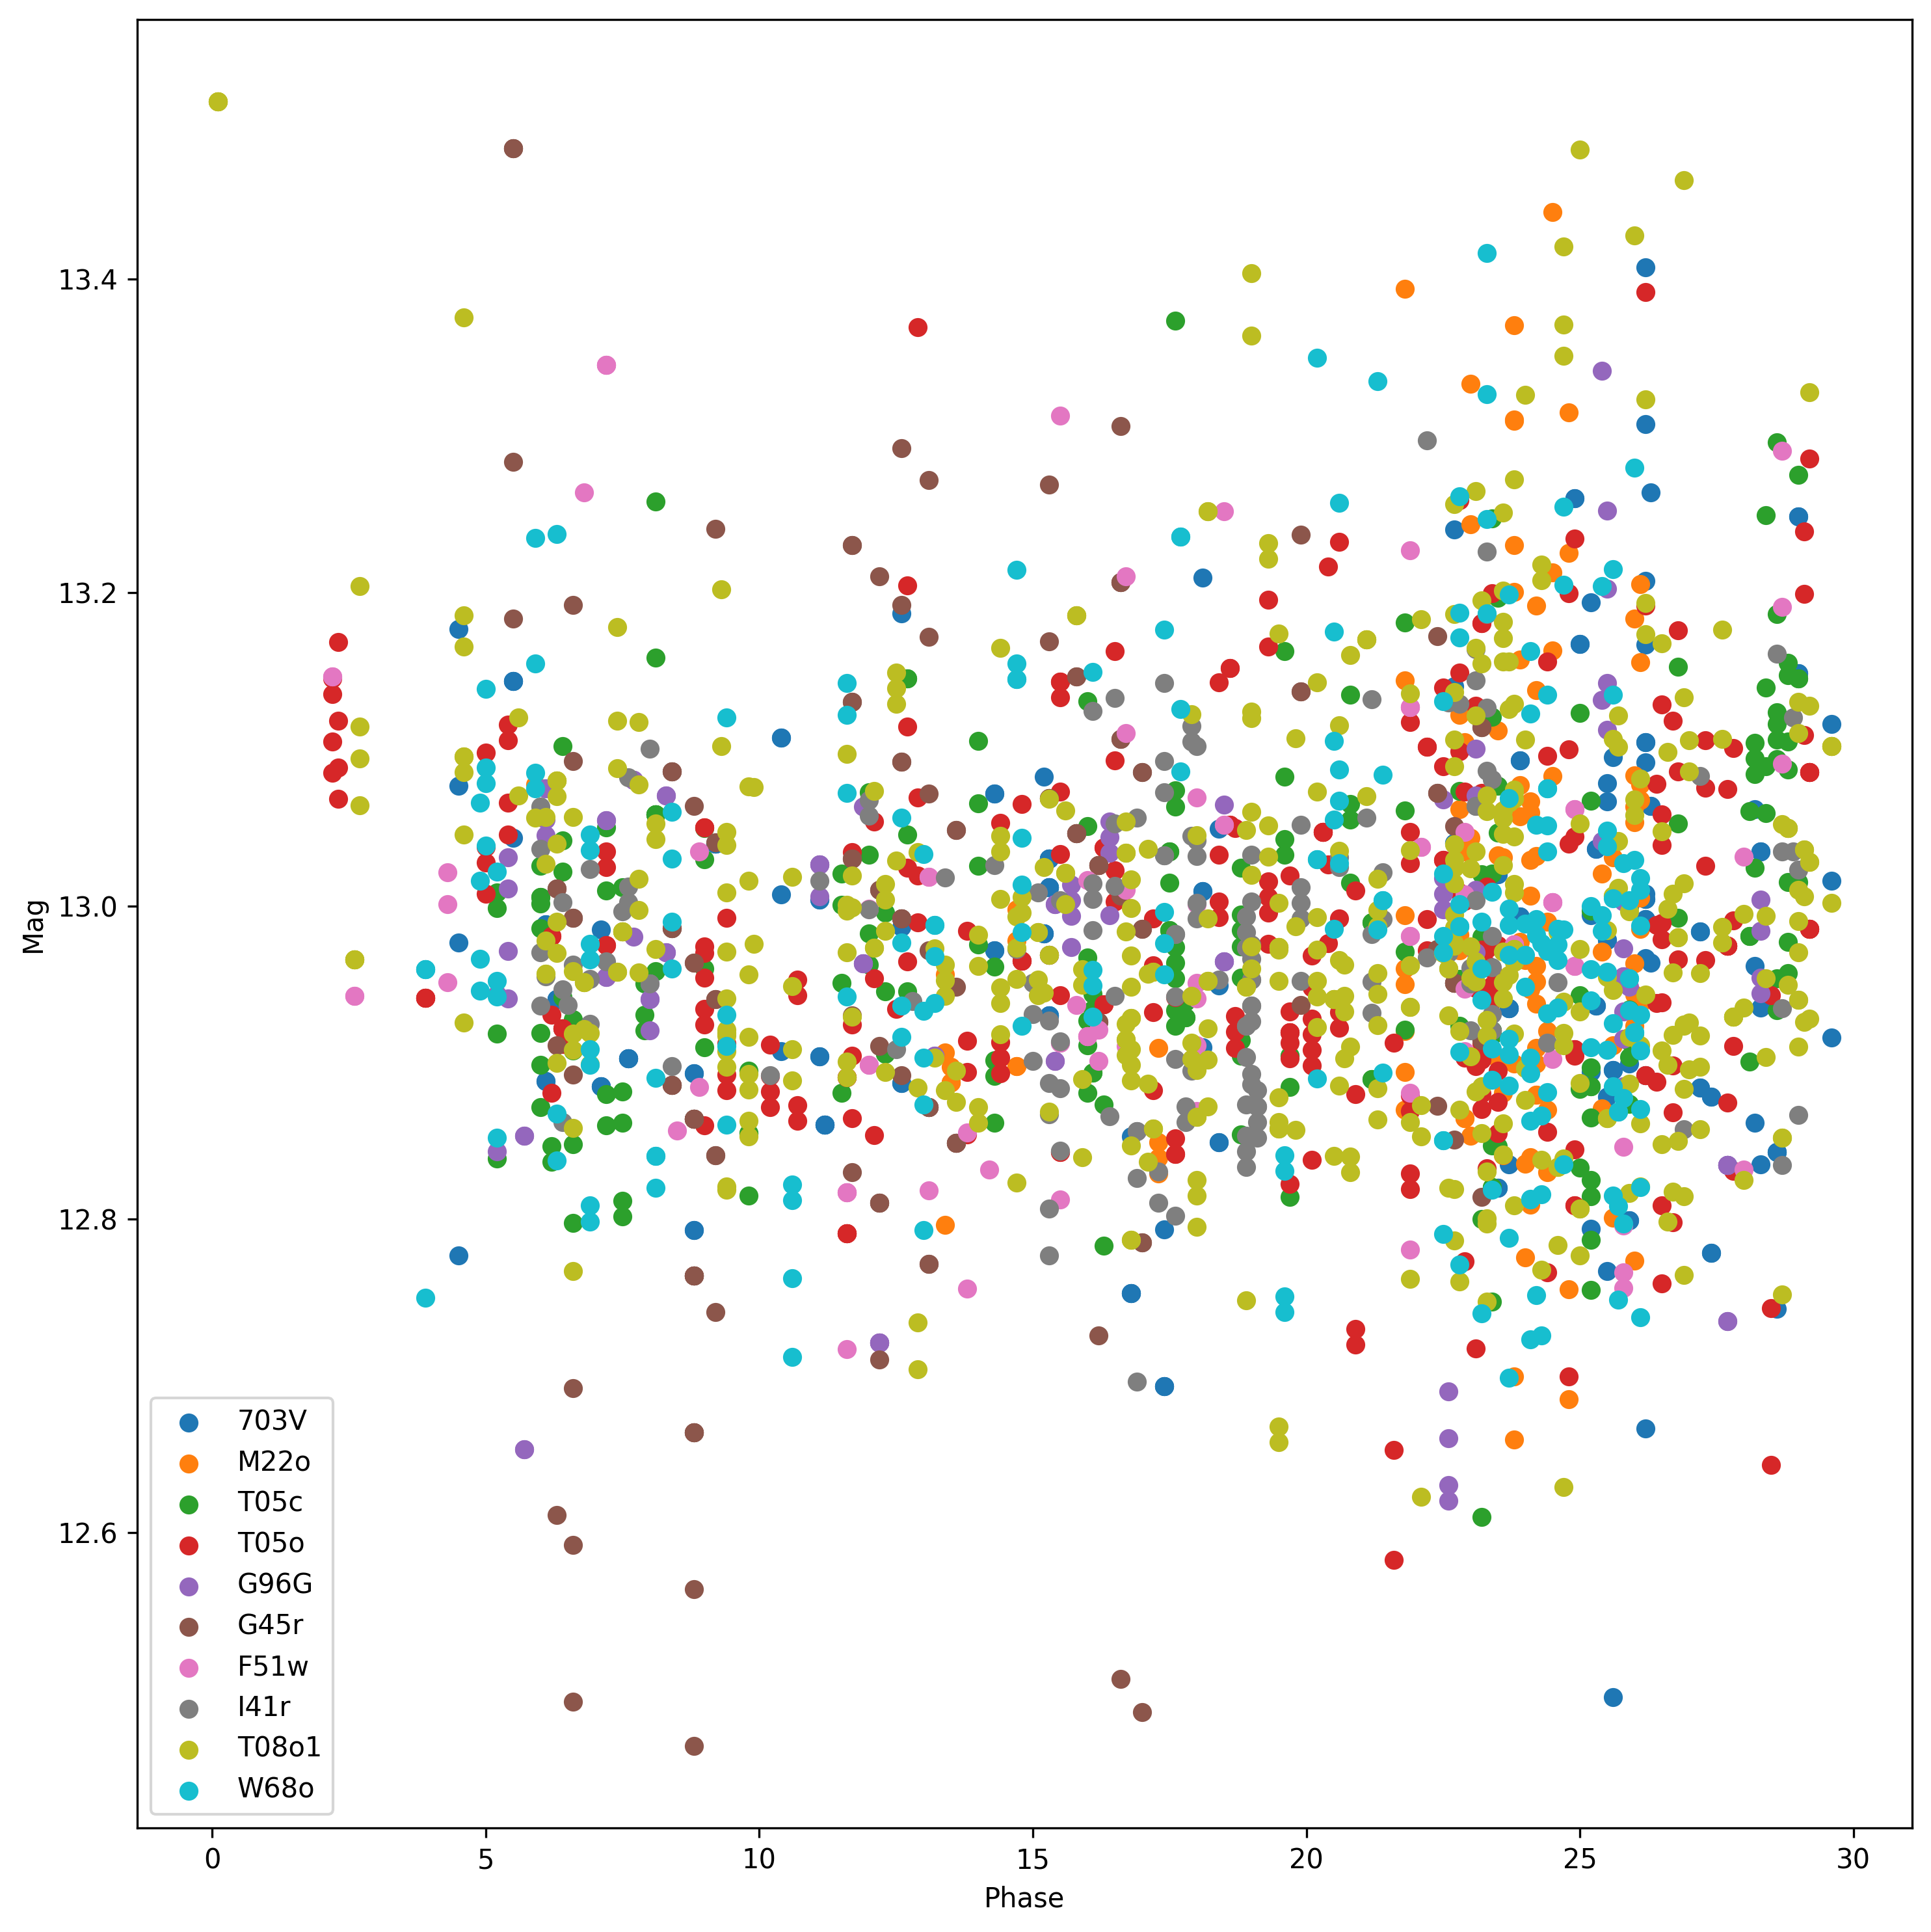

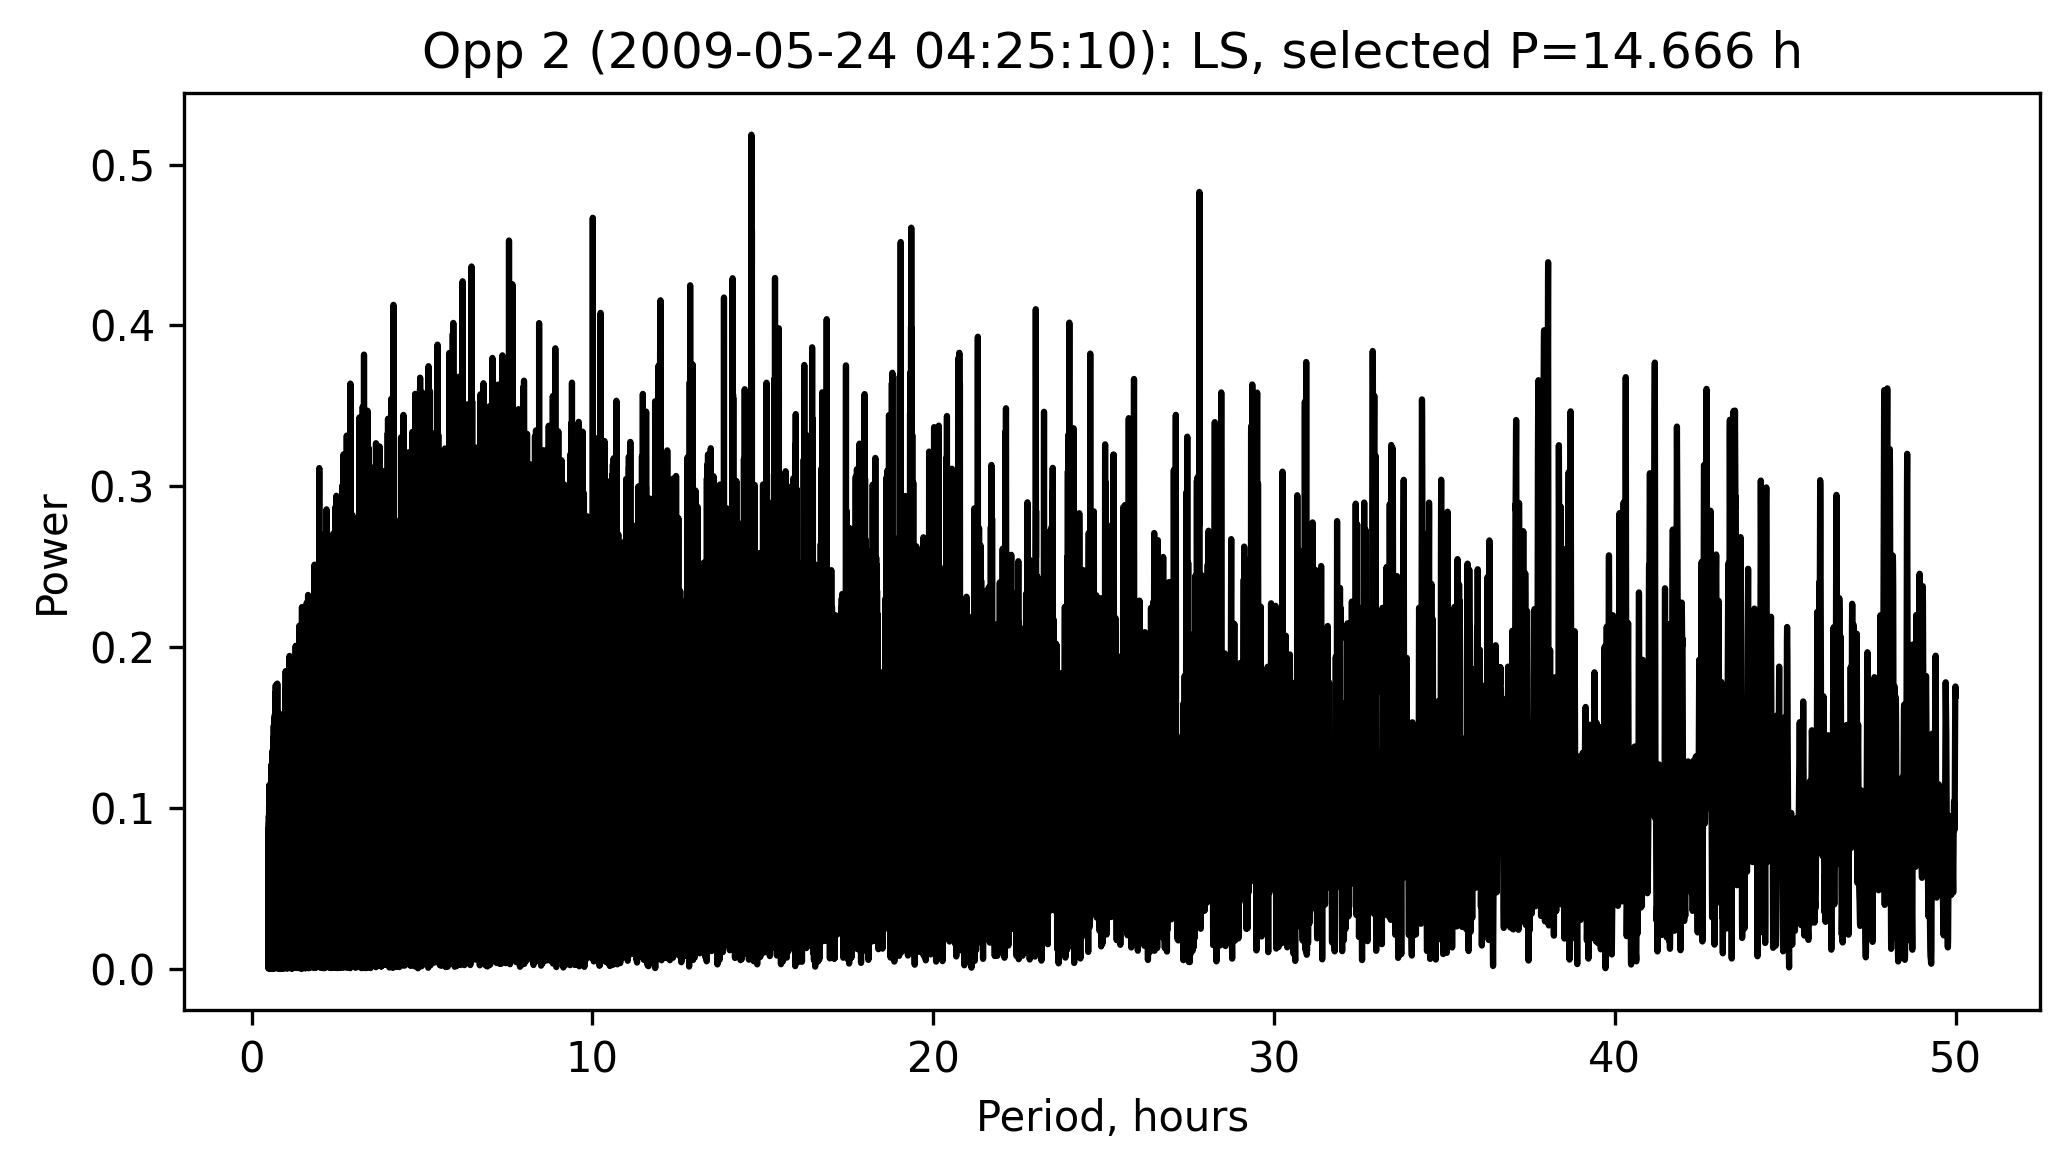

Opposition 3 (2016-06-23 04:25:10): top periods (hours)
     Period     power
0  4.227777  0.247969
1  4.227843  0.247808
2  4.227710  0.245521
3  8.458115  0.245269
4  4.229045  0.244735
Opposition 3: selected period = 8.4581 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=4.2278 h, P2=8.4581 h)


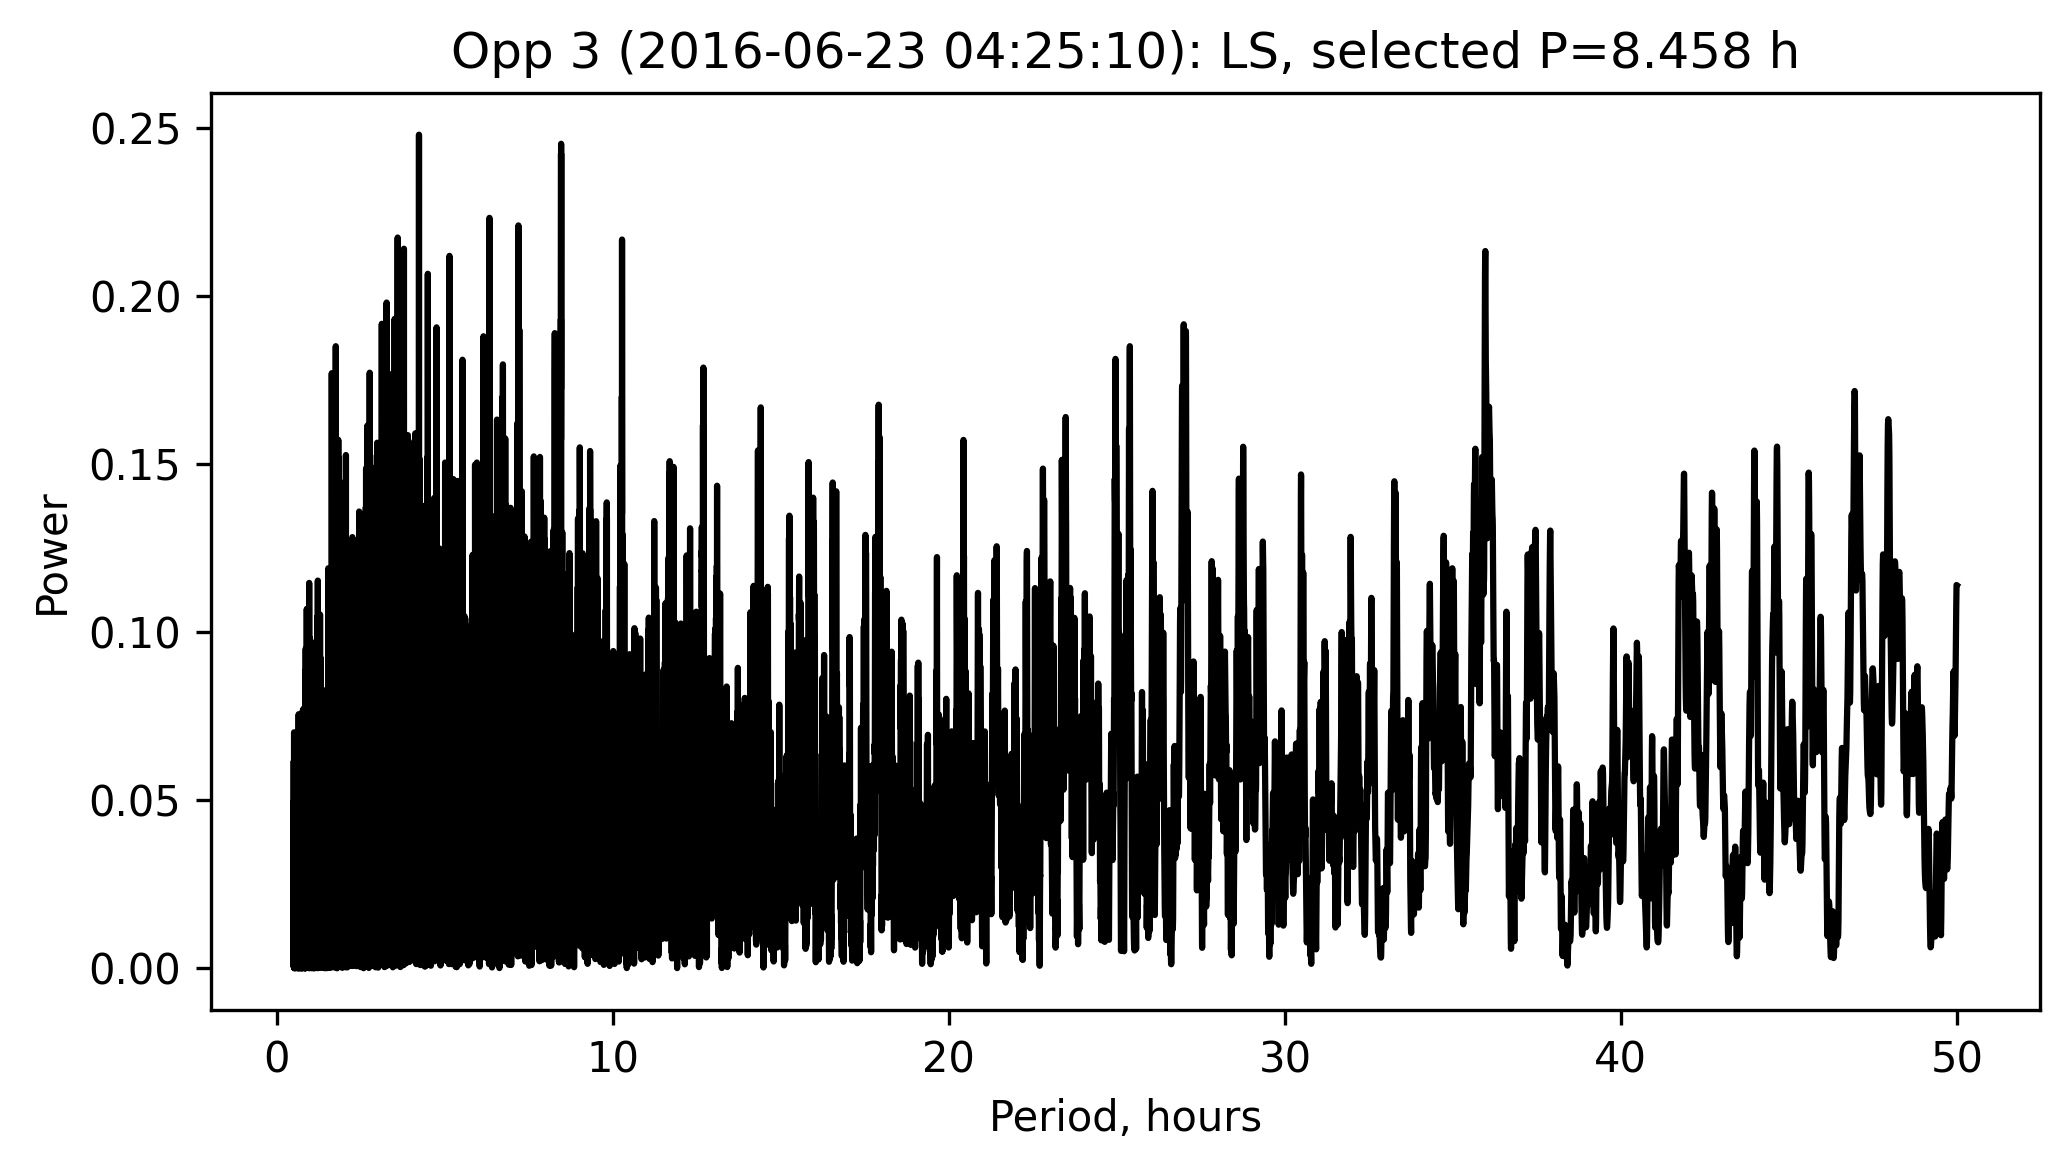

Opposition 4 (2017-12-08 04:25:10): top periods (hours)
      Period     power
0  23.941535  0.419442
1  23.947965  0.407515
2  23.935108  0.401300
3  11.972885  0.396635
4  11.974493  0.395187
Opposition 4: selected period = 23.9415 h; reason: top period kept (extrema count: n_max=2, n_min=2)


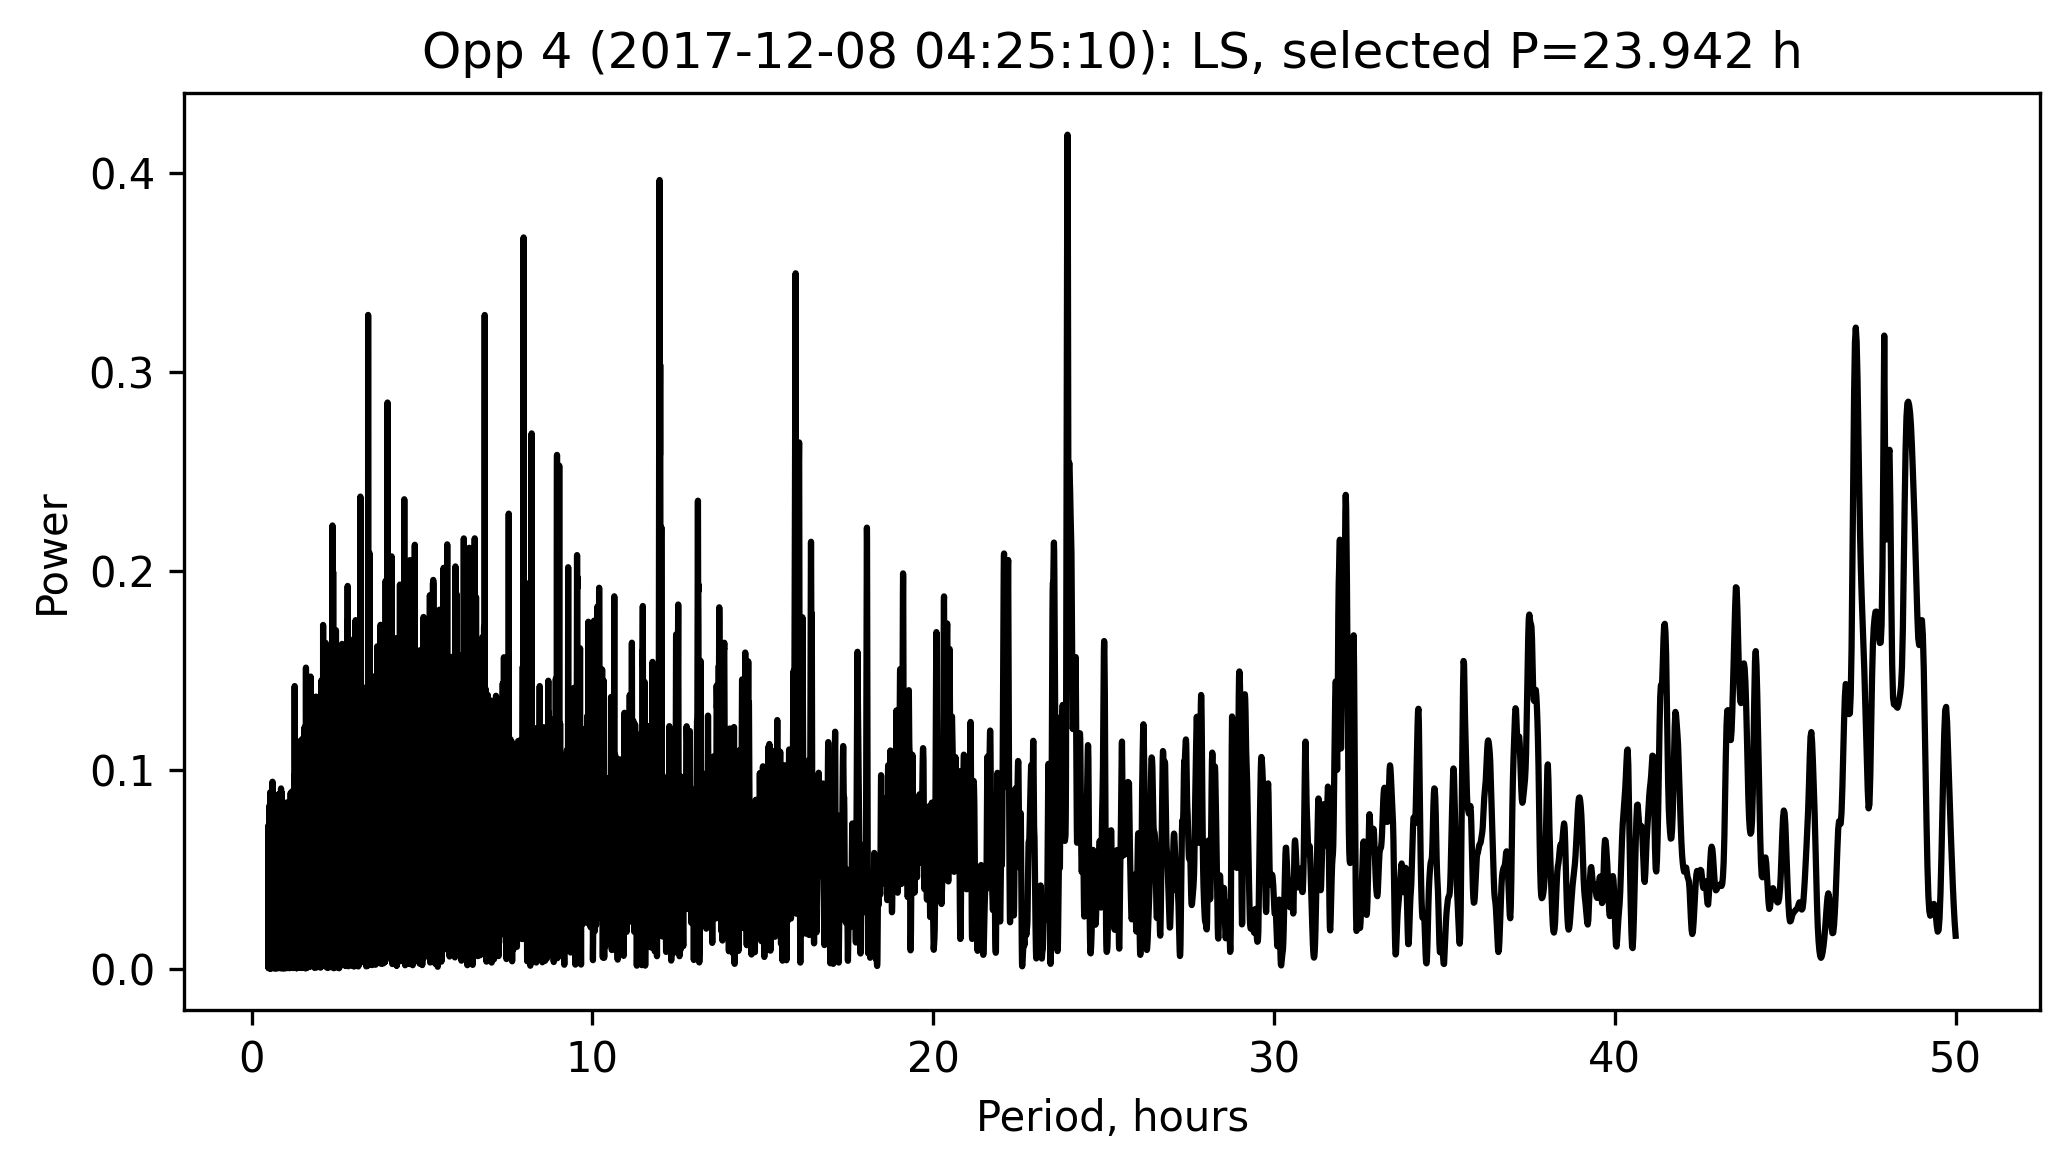

Opposition 5 (2019-05-12 04:25:10): top periods (hours)
     Period     power
0  4.490728  0.241388
1  2.245368  0.233319
2  2.245351  0.232818
3  4.490662  0.230707
4  2.245384  0.227124
Opposition 5: selected period = 4.4907 h; reason: top period kept (extrema count: n_max=2, n_min=2)


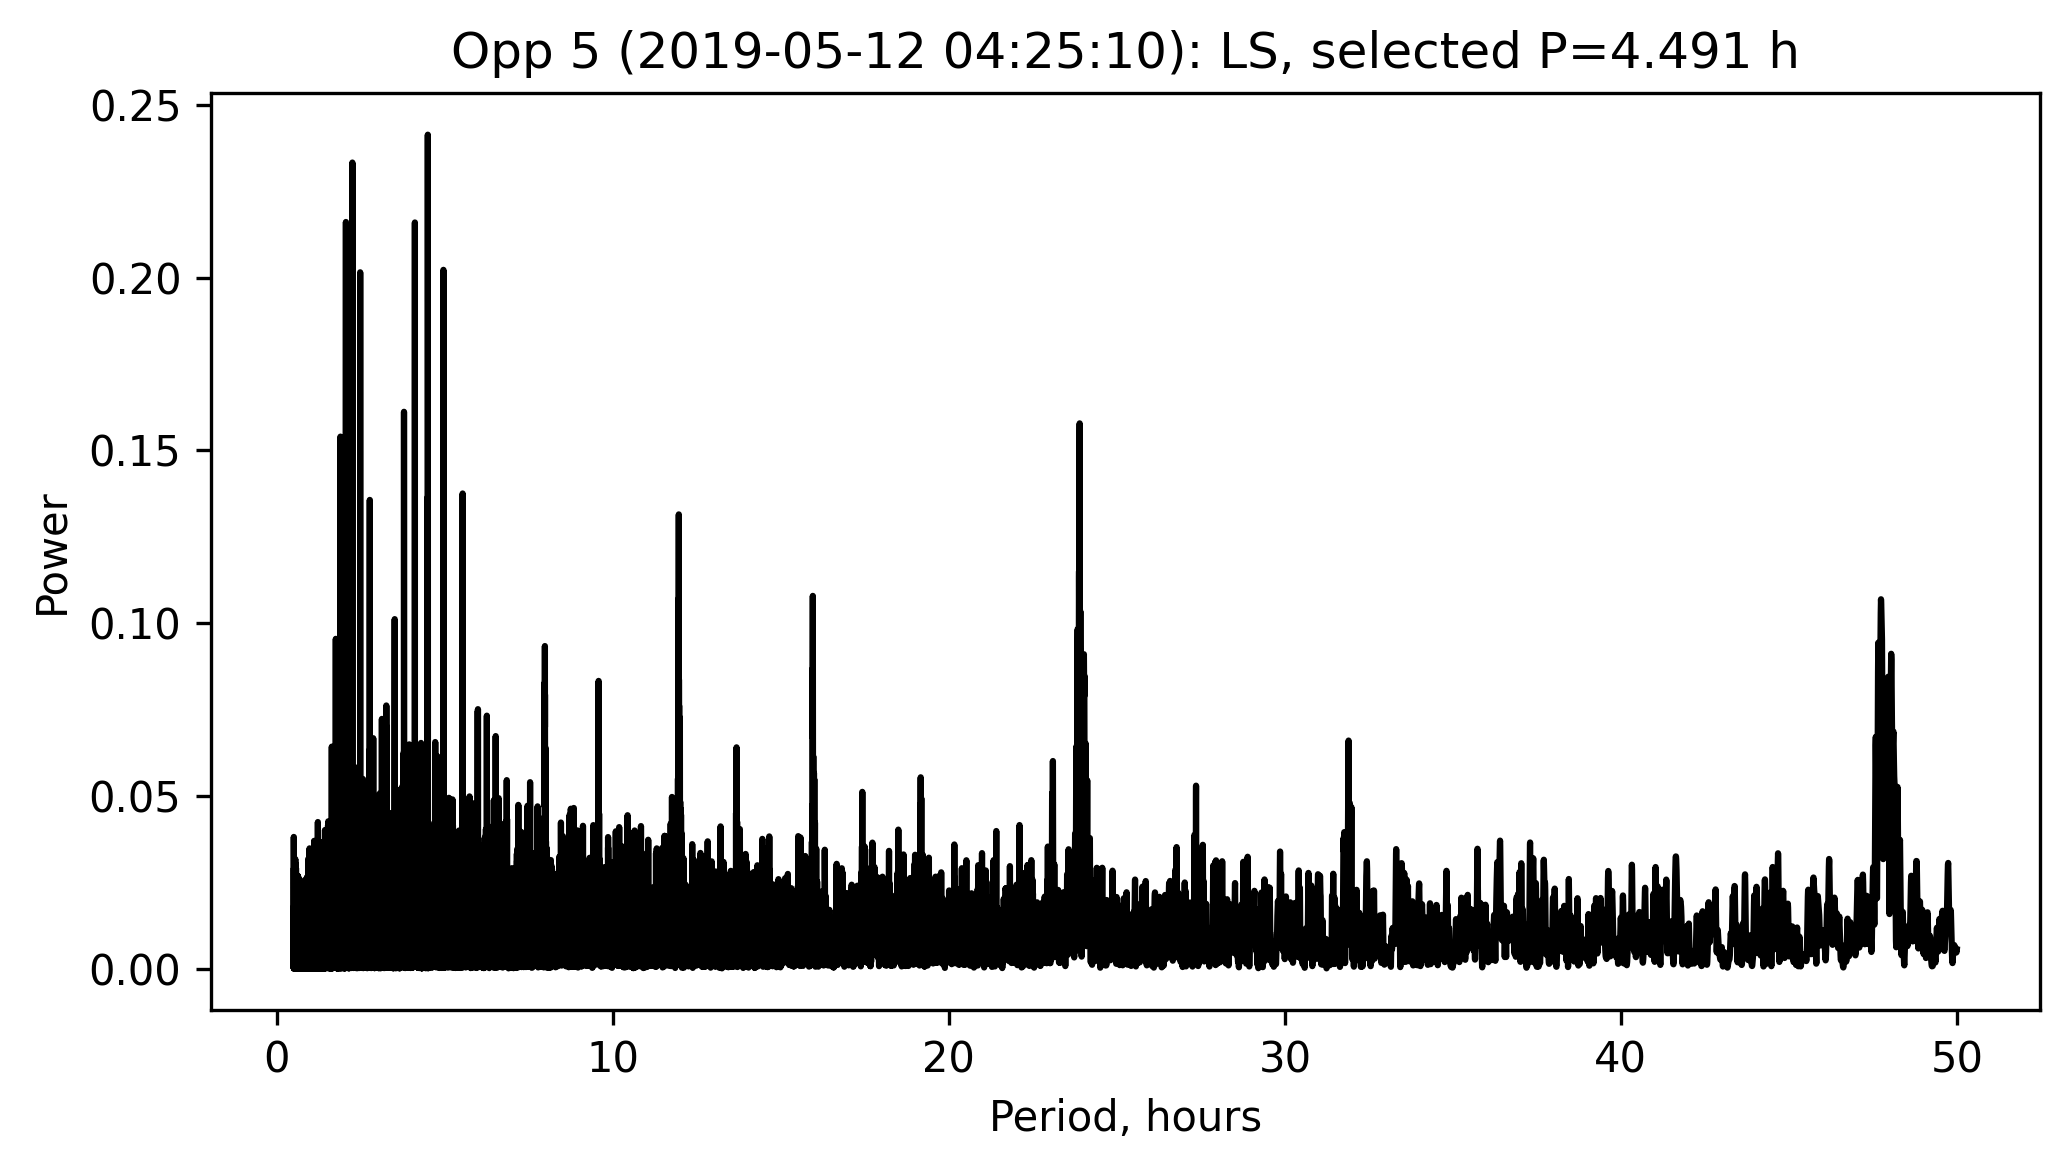

Opposition 6 (2023-07-28 04:25:10): top periods (hours)
     Period     power
0  4.490651  0.175516
1  2.245334  0.173871
2  2.245317  0.171462
3  2.245351  0.170117
4  4.490719  0.167967
Opposition 6: selected period = 4.4907 h; reason: top period kept (extrema count: n_max=2, n_min=2)


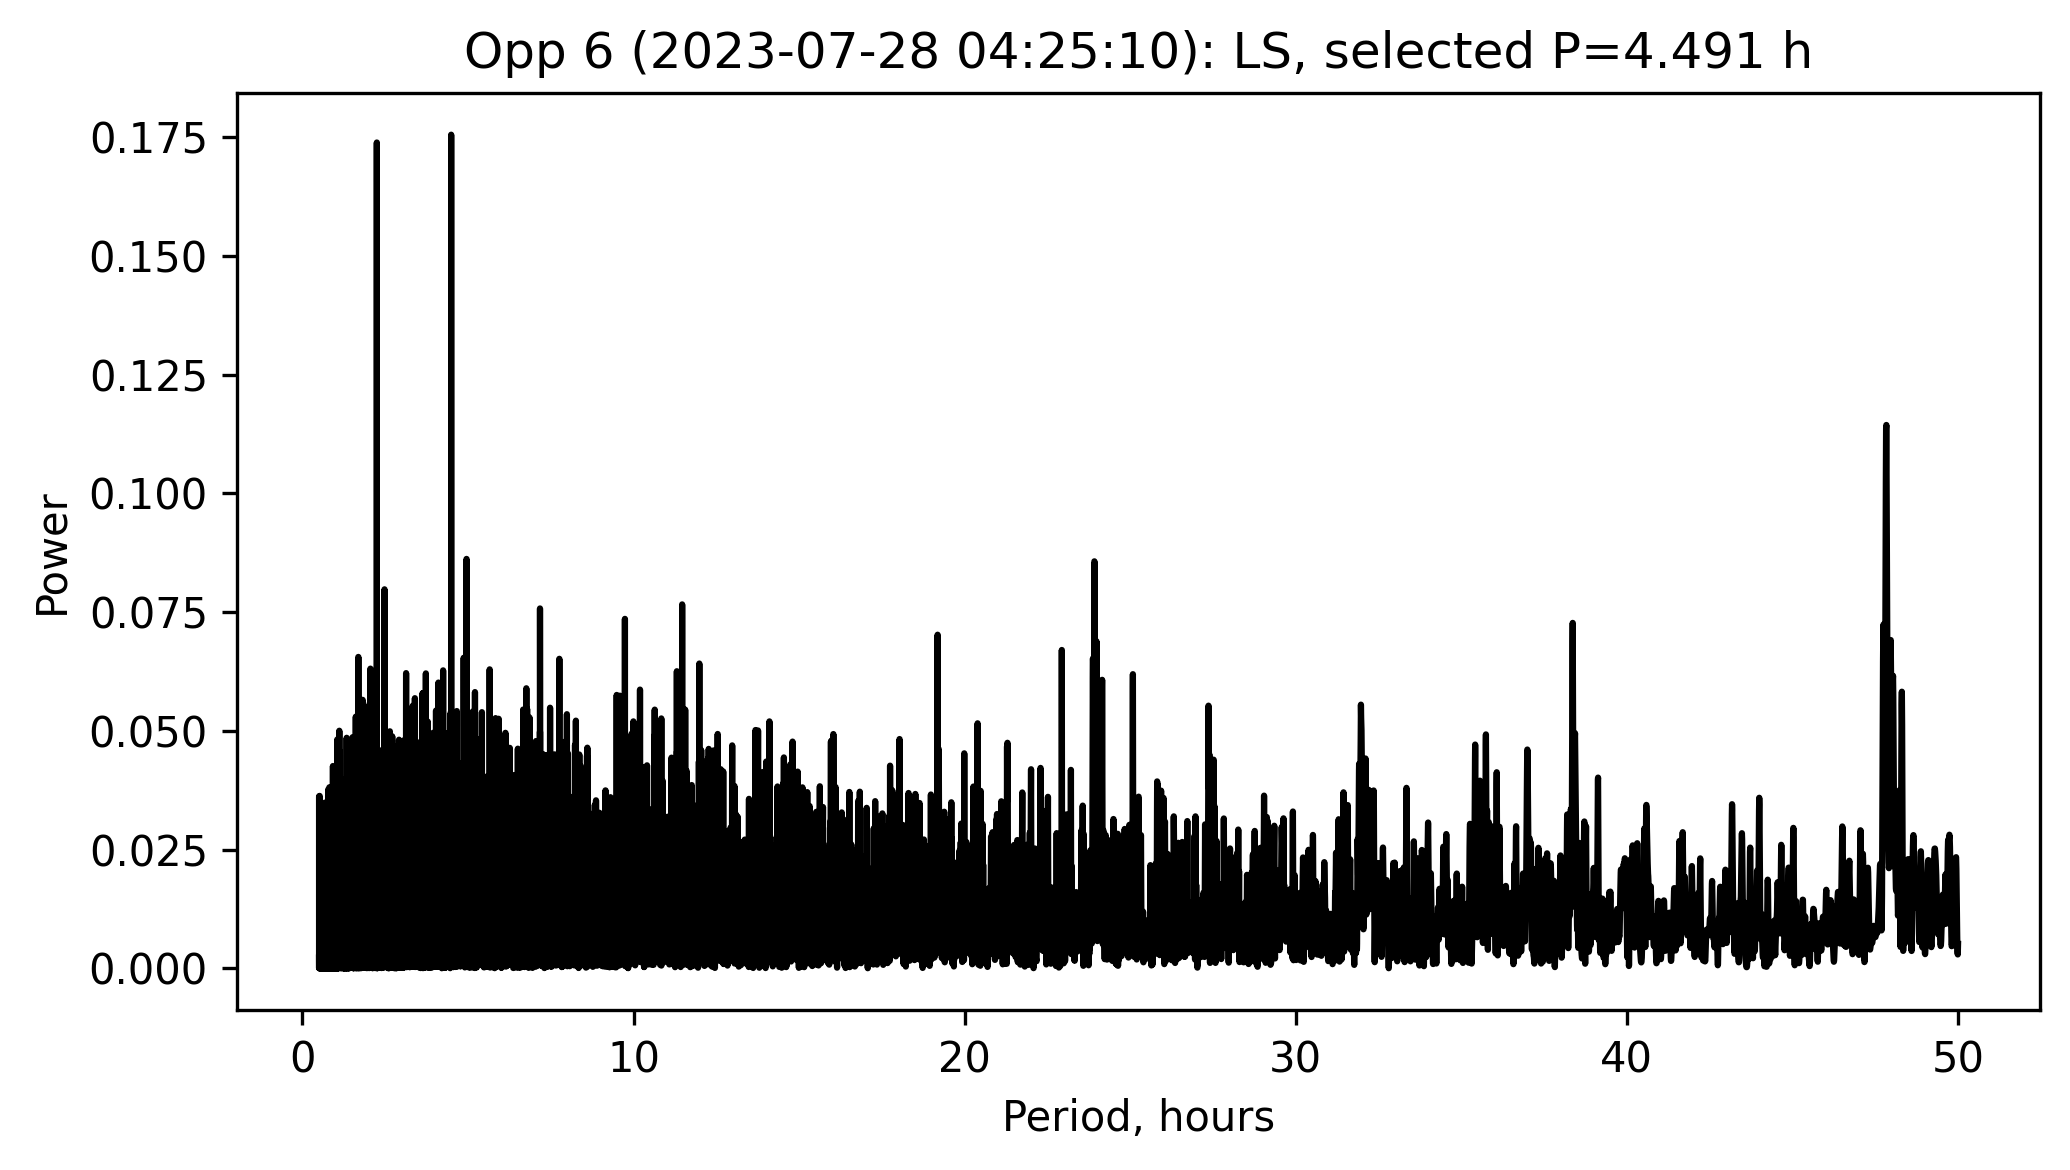

c:\Users\kn18001\Documents\Asteroids\Combined-dataset-period-analysis\asteroid_ls.py:591: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=1)


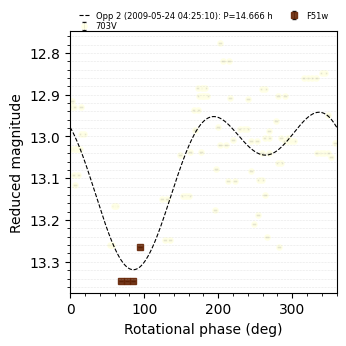

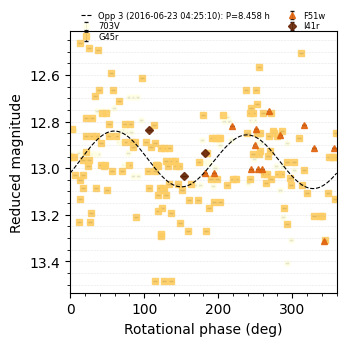

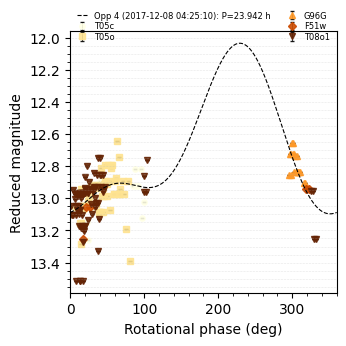

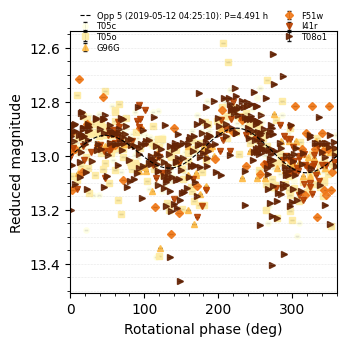

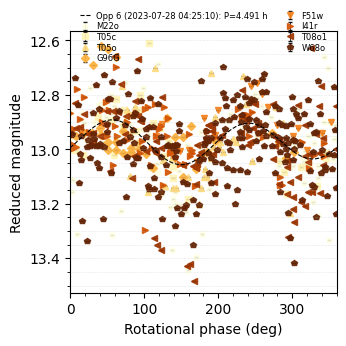

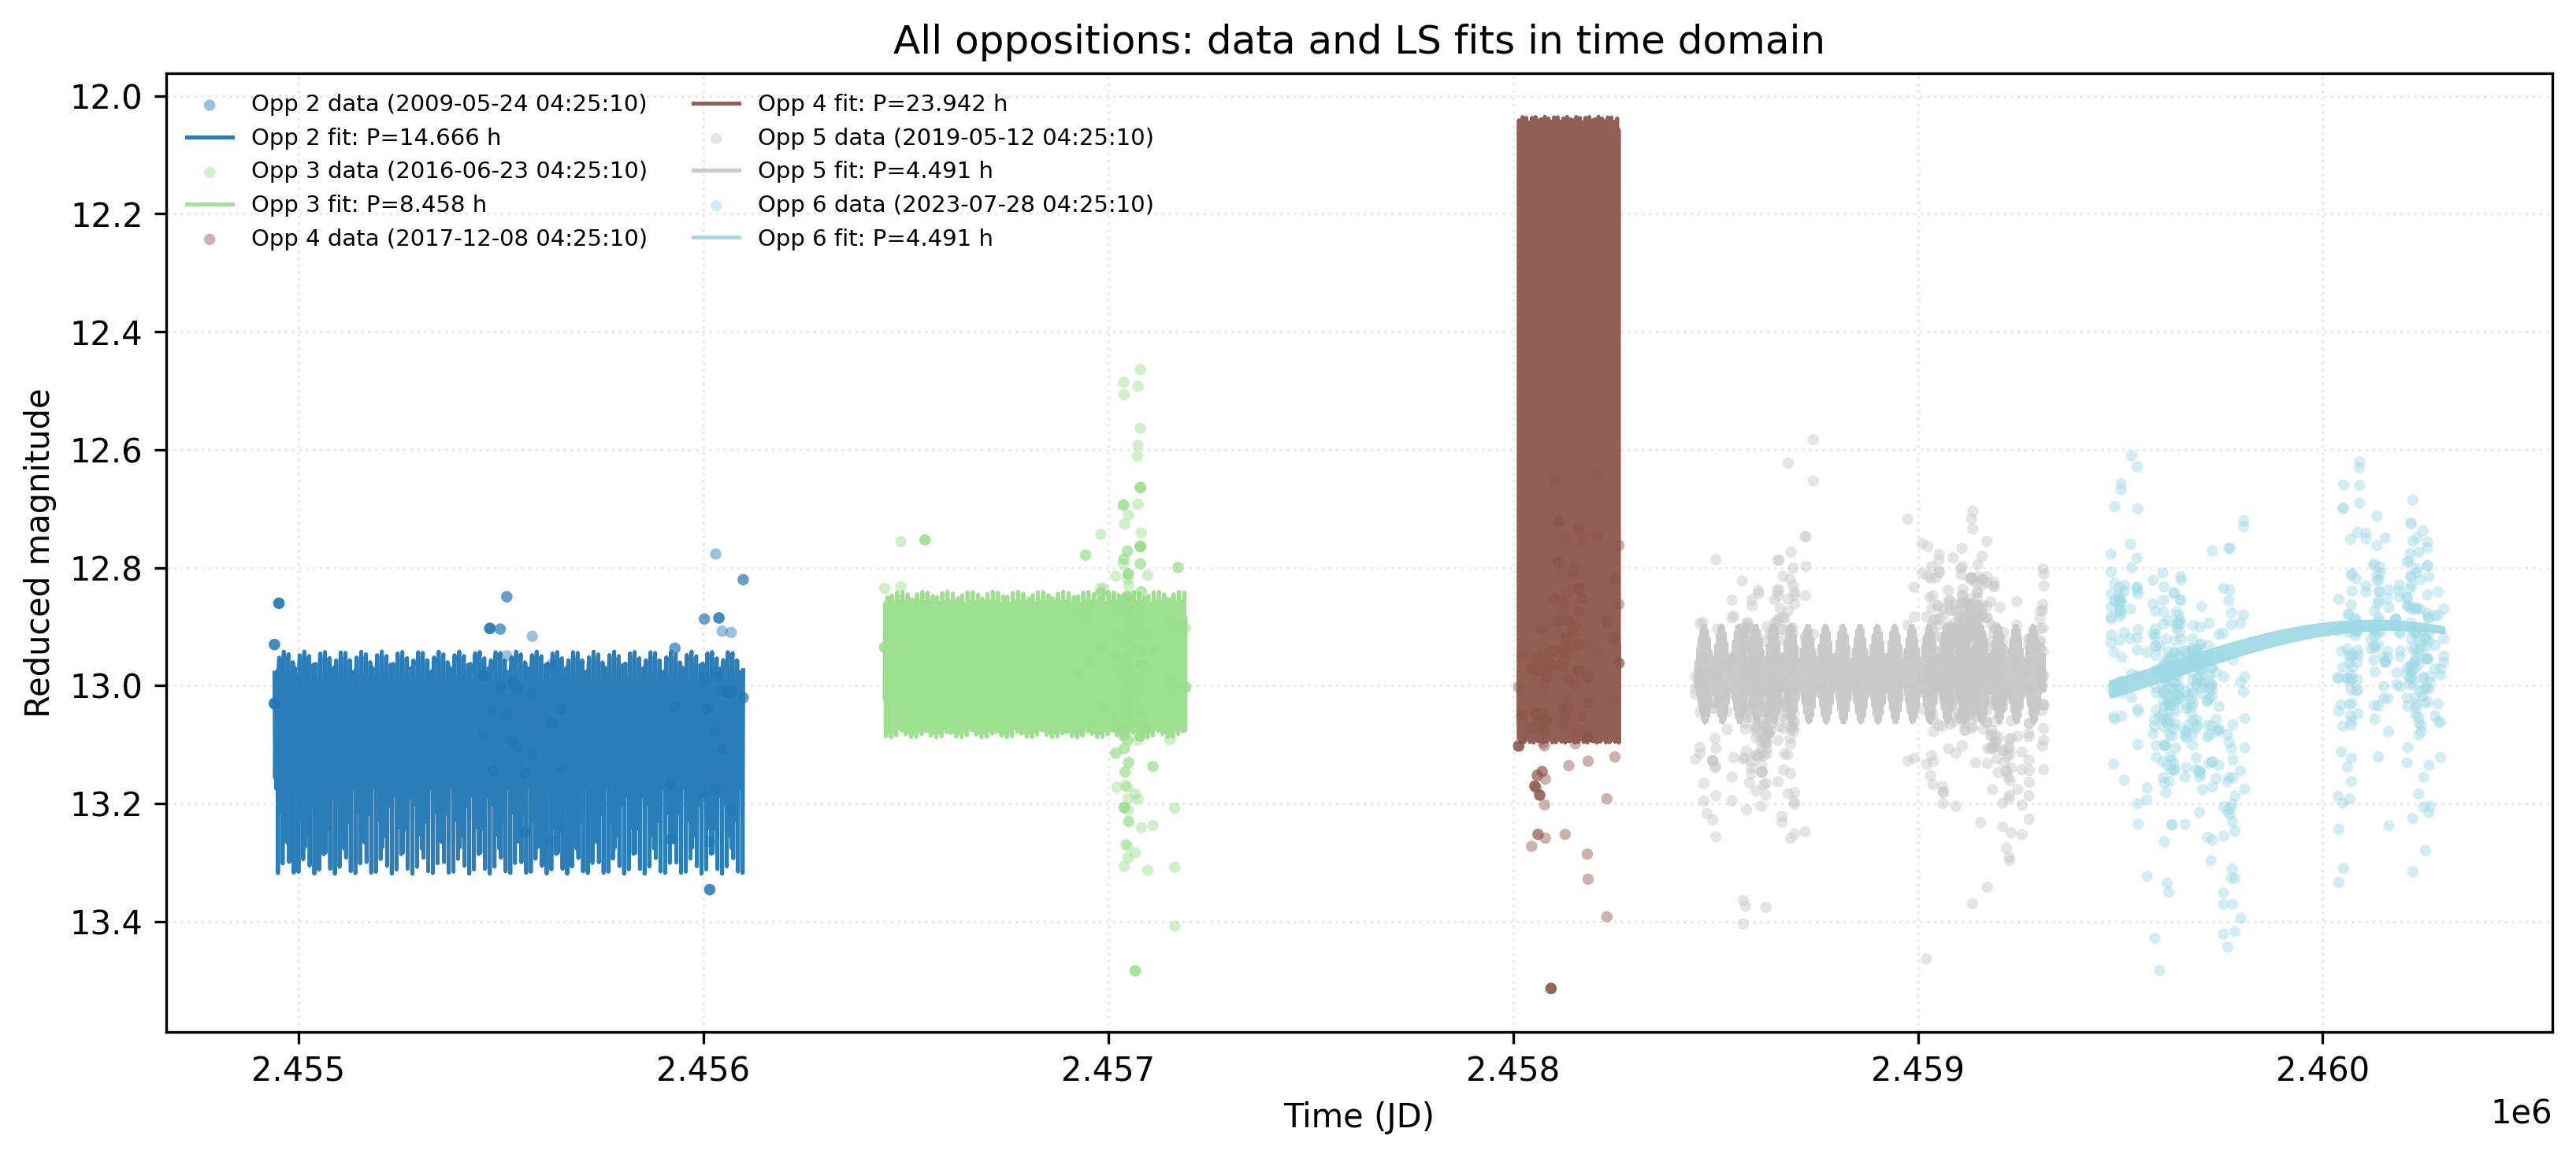

In [4]:
Asteroid_number= 2971
path_of_dict = r"../Asteroid_data/Plots_and_data/{}_data_compile_fix_G1G2.pkl".format(Asteroid_number)
with open(path_of_dict, 'rb') as file:
        # Load the data from the file
        dict_sheets = pickle.load(file)


pipe = AsteroidLSPipeline(dict_sheets, Asteroid_number=Asteroid_number)

opp_data = pipe.reading_data(
    split_oppositions=True,
    opposition_method="horizons",
    min_obs_per_opposition=50,
)

opp_ls = pipe.LS_initiate_per_opposition(
    opposition_data=opp_data,
    nterms=2,
    peak_idx=0,
    double_period_tol=0.12,
)

pipe.visualize_ls_per_opposition(opp_ls)
pipe.visualize_time_series_all_oppositions(opp_ls)

M22o
T05c
T05o
703G
703V
T08o
D29R
G45r
G96G
I41r
W68o
Detected opposition epochs from Horizons:
  Opp 0: JD=2453338.720, UTC=2004-11-29 05:16:54, elong=177.24 deg
  Opp 1: JD=2455939.720, UTC=2012-01-13 05:16:54, elong=173.14 deg
  Opp 2: JD=2456434.720, UTC=2013-05-22 05:16:54, elong=174.61 deg
  Opp 3: JD=2457010.720, UTC=2014-12-19 05:16:54, elong=178.20 deg
  Opp 4: JD=2458076.720, UTC=2017-11-19 05:16:54, elong=174.84 deg
  Opp 5: JD=2459609.720, UTC=2022-01-30 05:16:54, elong=170.42 deg
Opposition 0: date=2004-11-29 05:16:54, total observations=80
Opposition 0 (2004-11-29 05:16:54): 80 points, kept 80 after outlier filtering
Opposition 1: date=2012-01-13 05:16:54, total observations=77
Opposition 1 (2012-01-13 05:16:54): 77 points, kept 77 after outlier filtering
Opposition 2: date=2013-05-22 05:16:54, total observations=15
Opposition 2: discarded (n=15 < 50)
Opposition 3: date=2014-12-19 05:16:54, total observations=191
Opposition 3 (2014-12-19 05:16:54): 191 points, kept 191 a

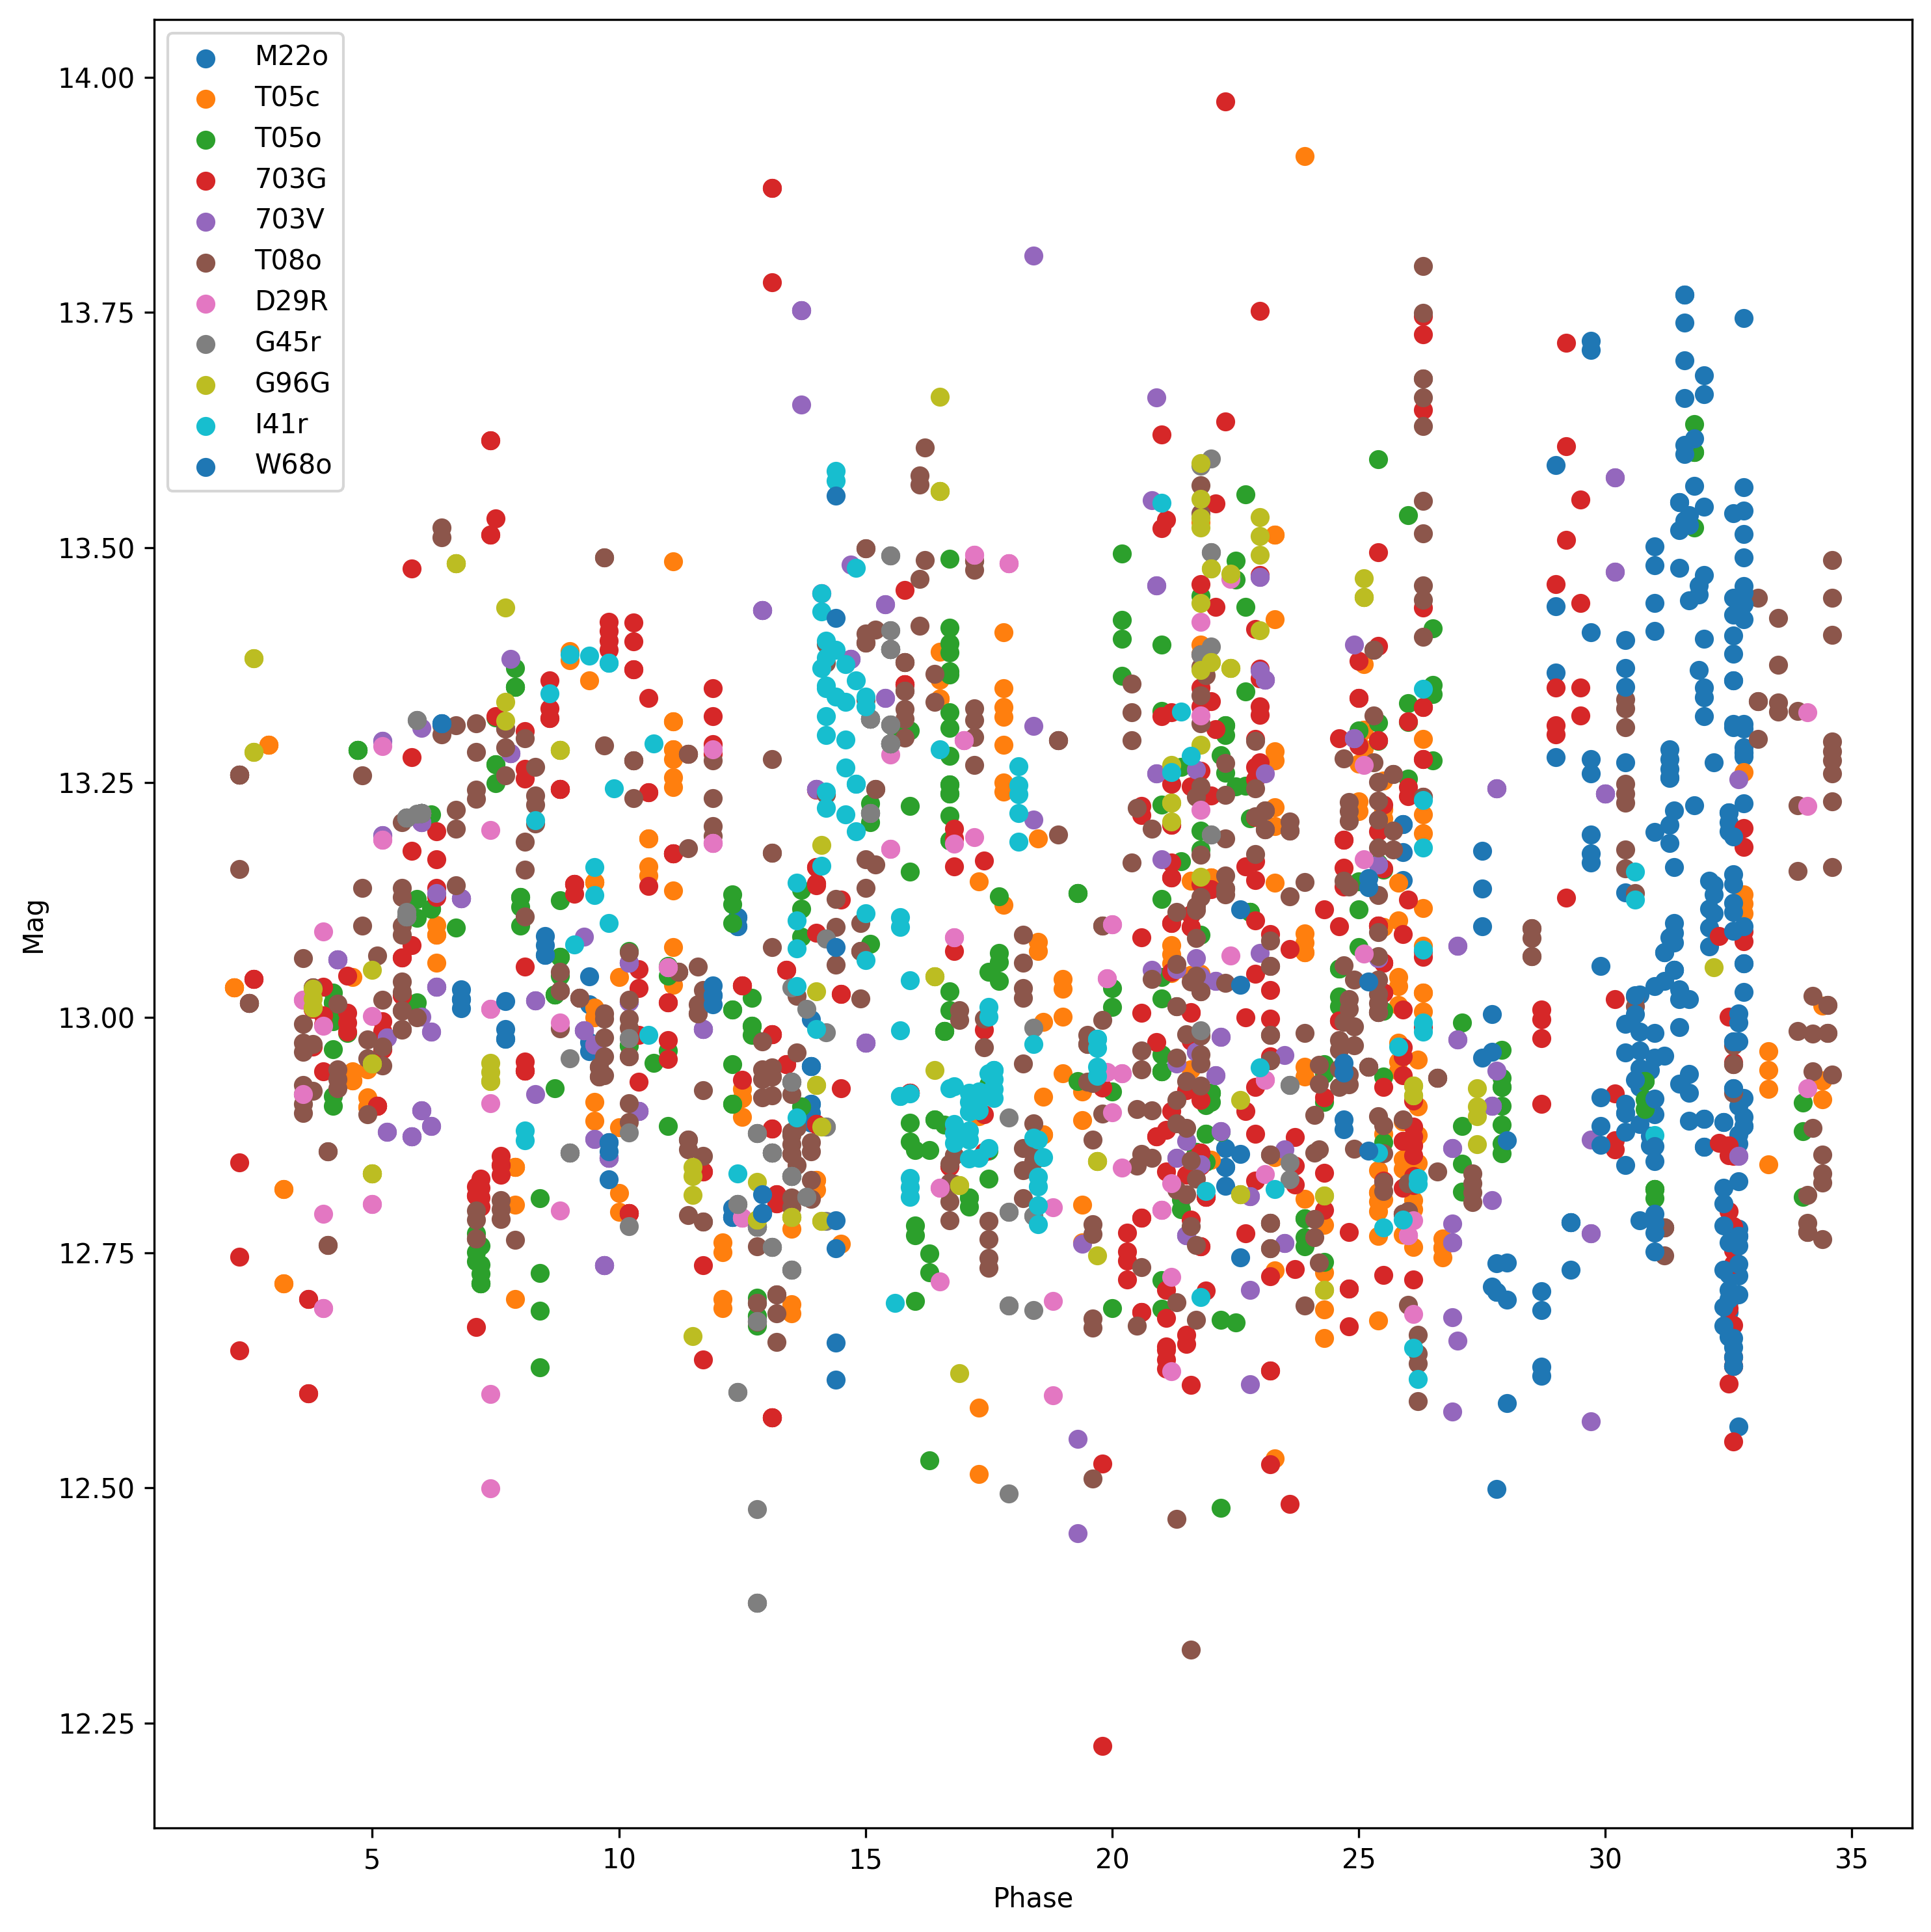

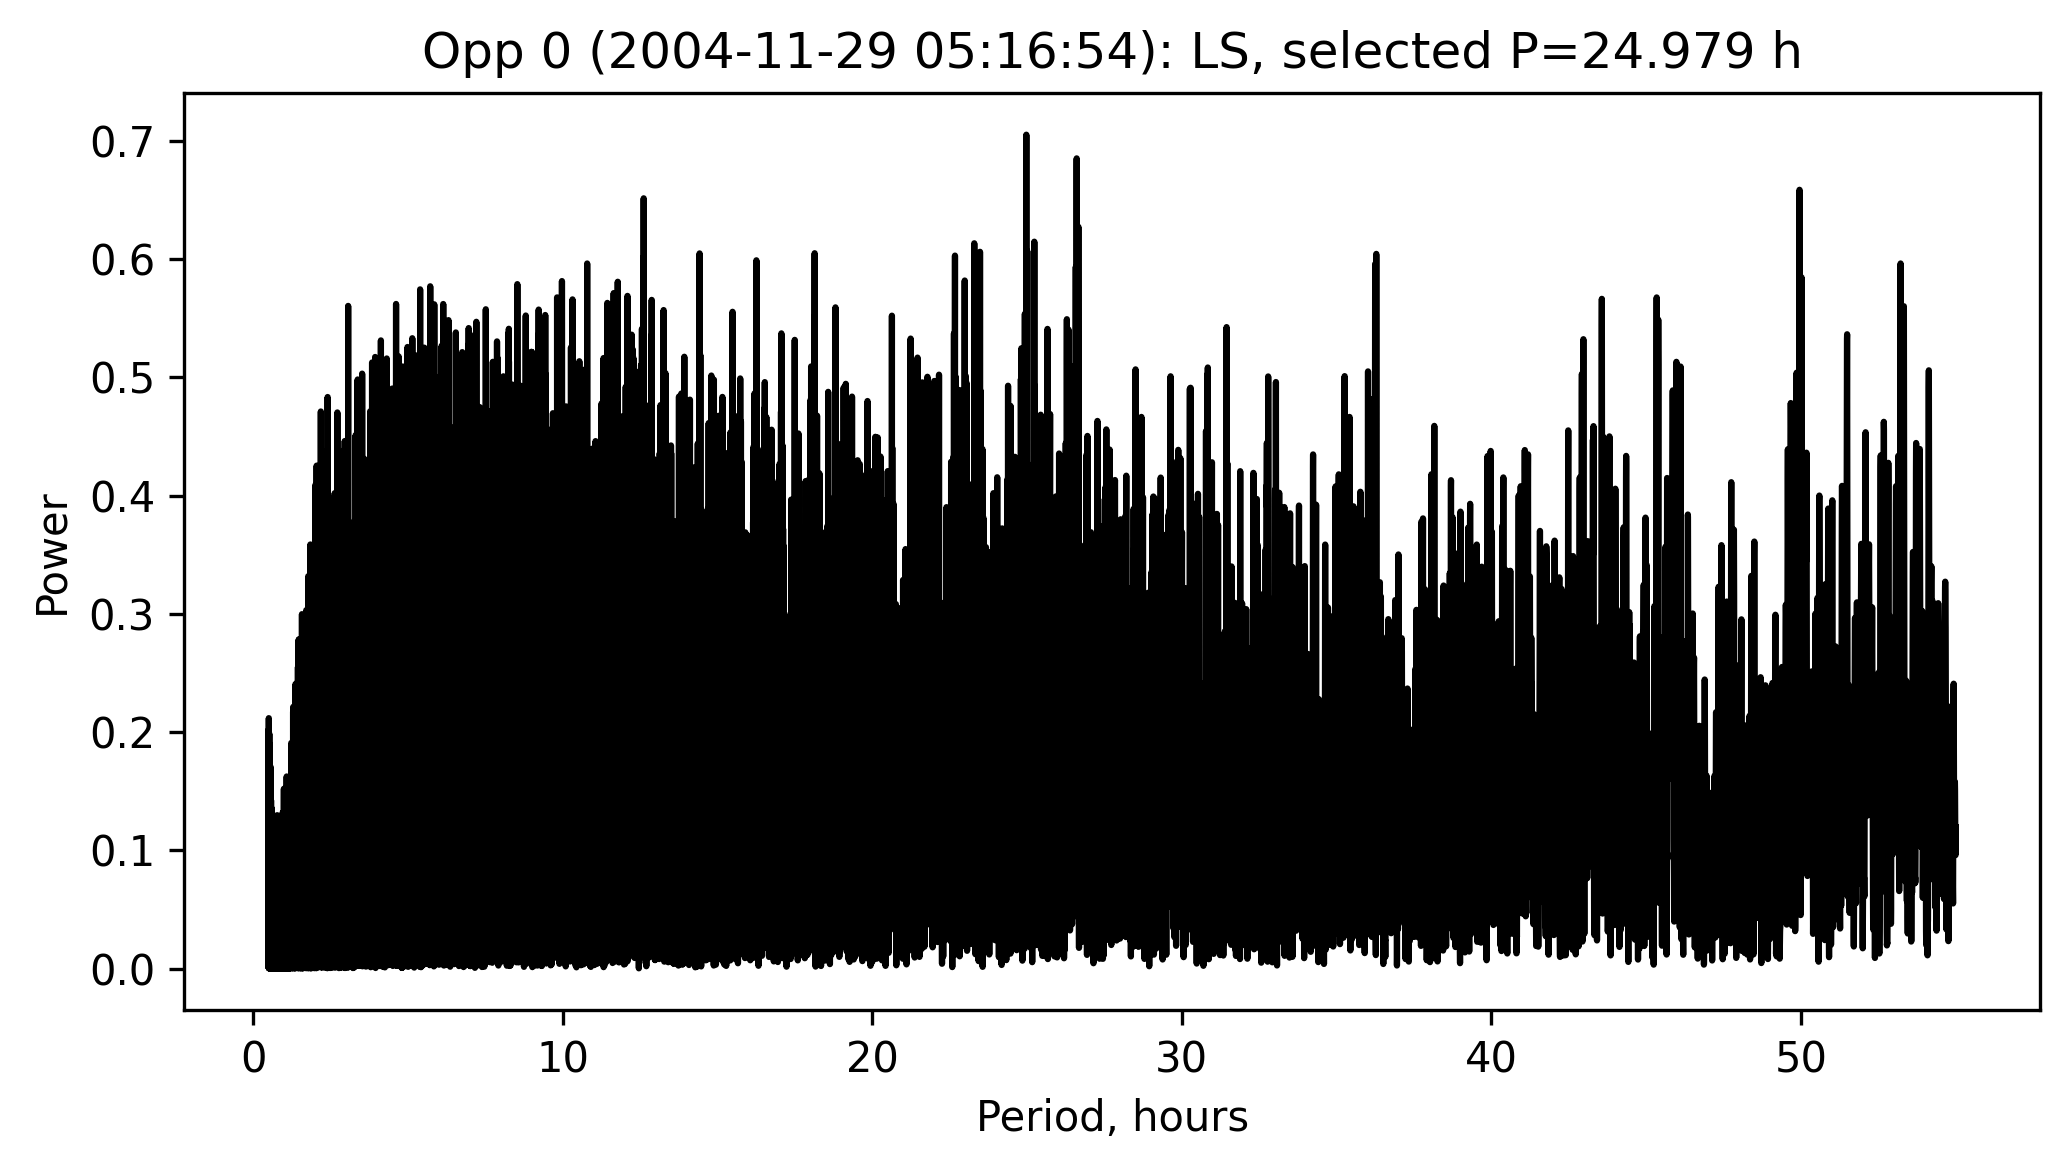

Opposition 1 (2012-01-13 05:16:54): top periods (hours)
      Period     power
0  10.935109  0.713010
1  10.686224  0.698838
2   7.507829  0.695058
3   7.507698  0.693542
4  21.868580  0.687251
Opposition 1: selected period = 10.9351 h; reason: top period kept (extrema count: n_max=2, n_min=2)


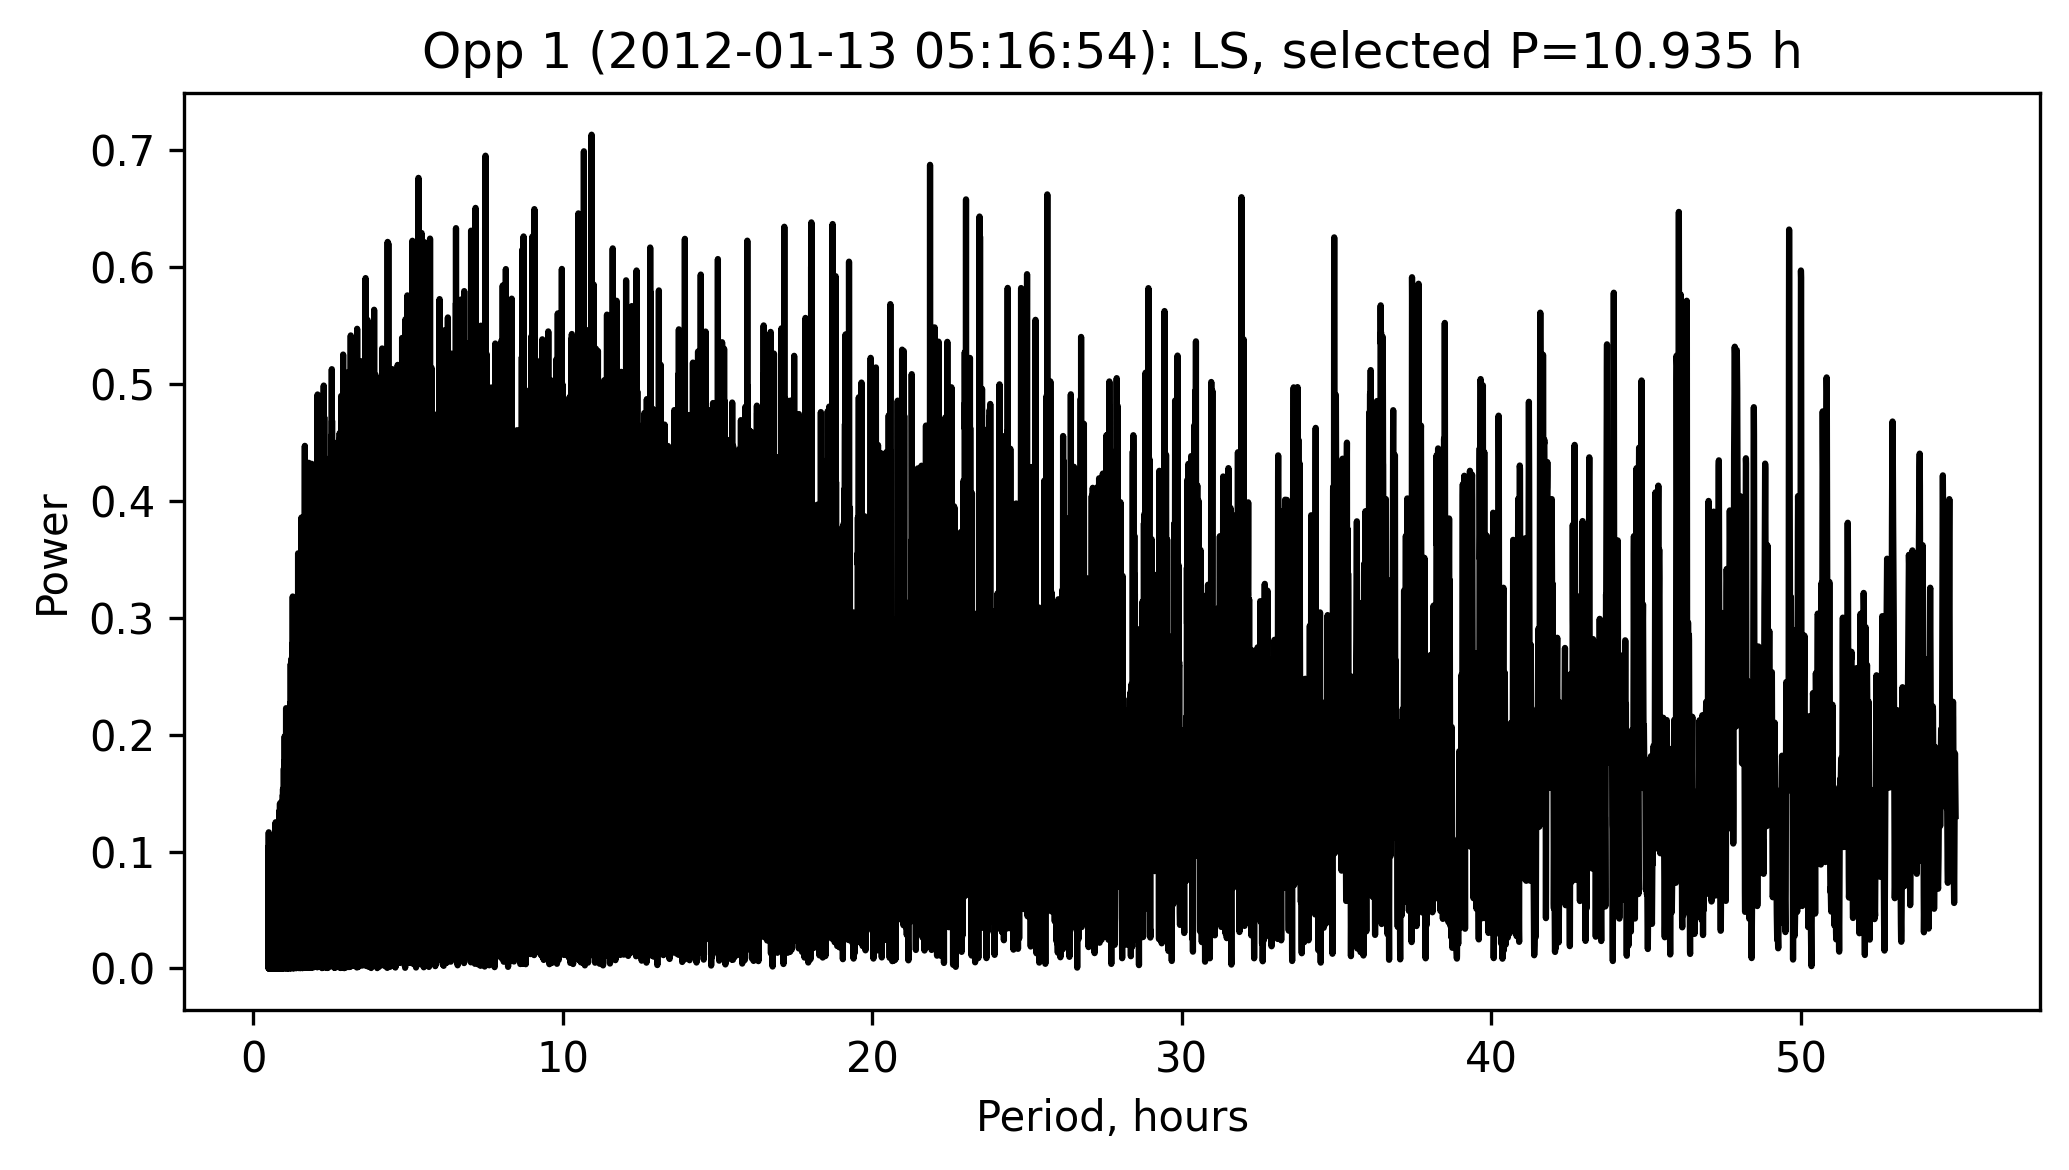

Opposition 3 (2014-12-19 05:16:54): top periods (hours)
      Period     power
0   8.095750  0.704469
1  49.989477  0.681866
2  24.992587  0.680697
3   8.095388  0.680318
4  24.989138  0.675770
Opposition 3: selected period = 16.1920 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=8.0958 h, P2=16.1920 h)


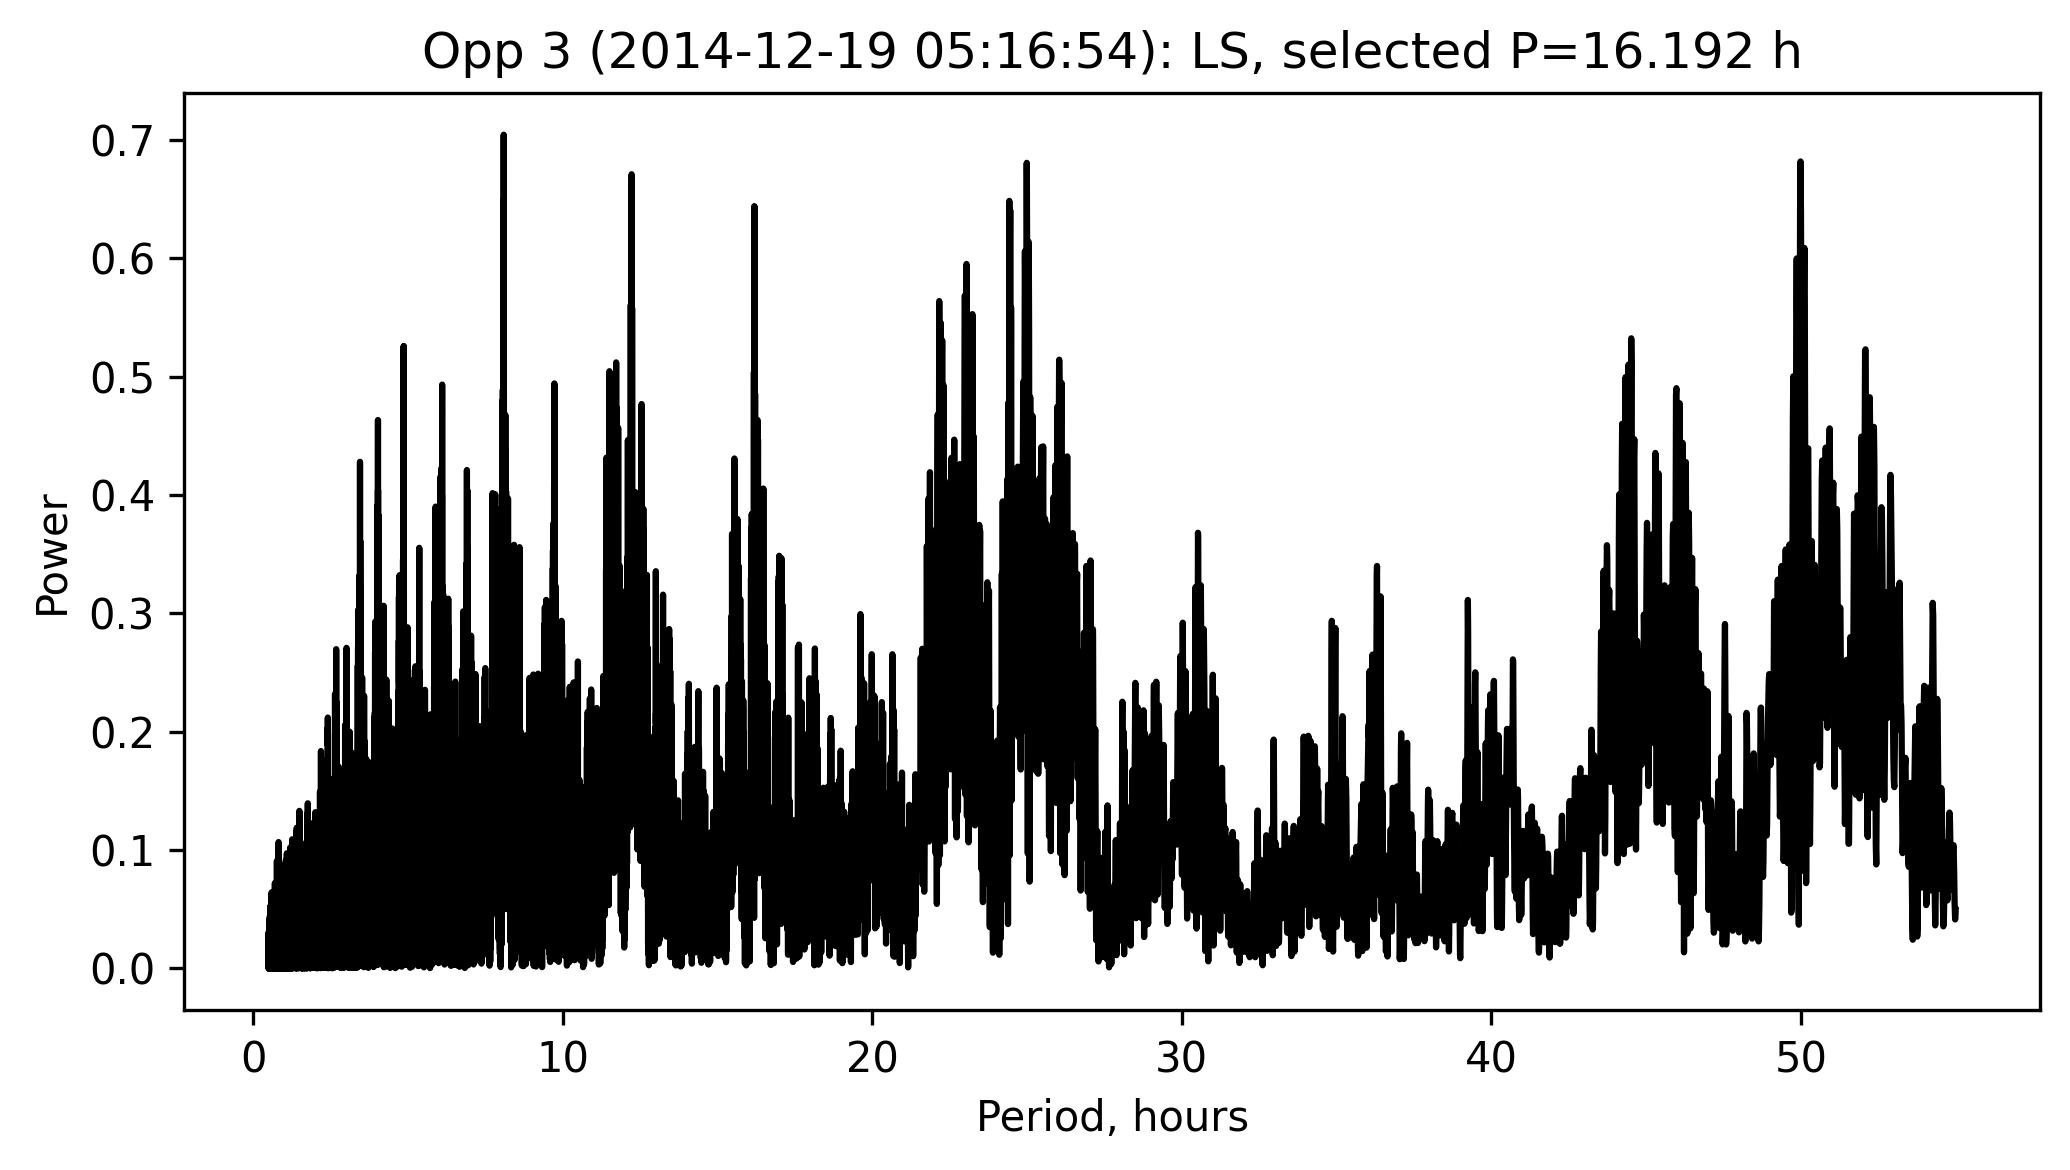

Opposition 4 (2017-11-19 05:16:54): top periods (hours)
      Period     power
0  24.983477  0.389984
1  24.981884  0.389931
2  49.963137  0.384059
3  49.969511  0.381755
4  24.980291  0.380968
Opposition 4: selected period = 49.9631 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=24.9835 h, P2=49.9631 h)


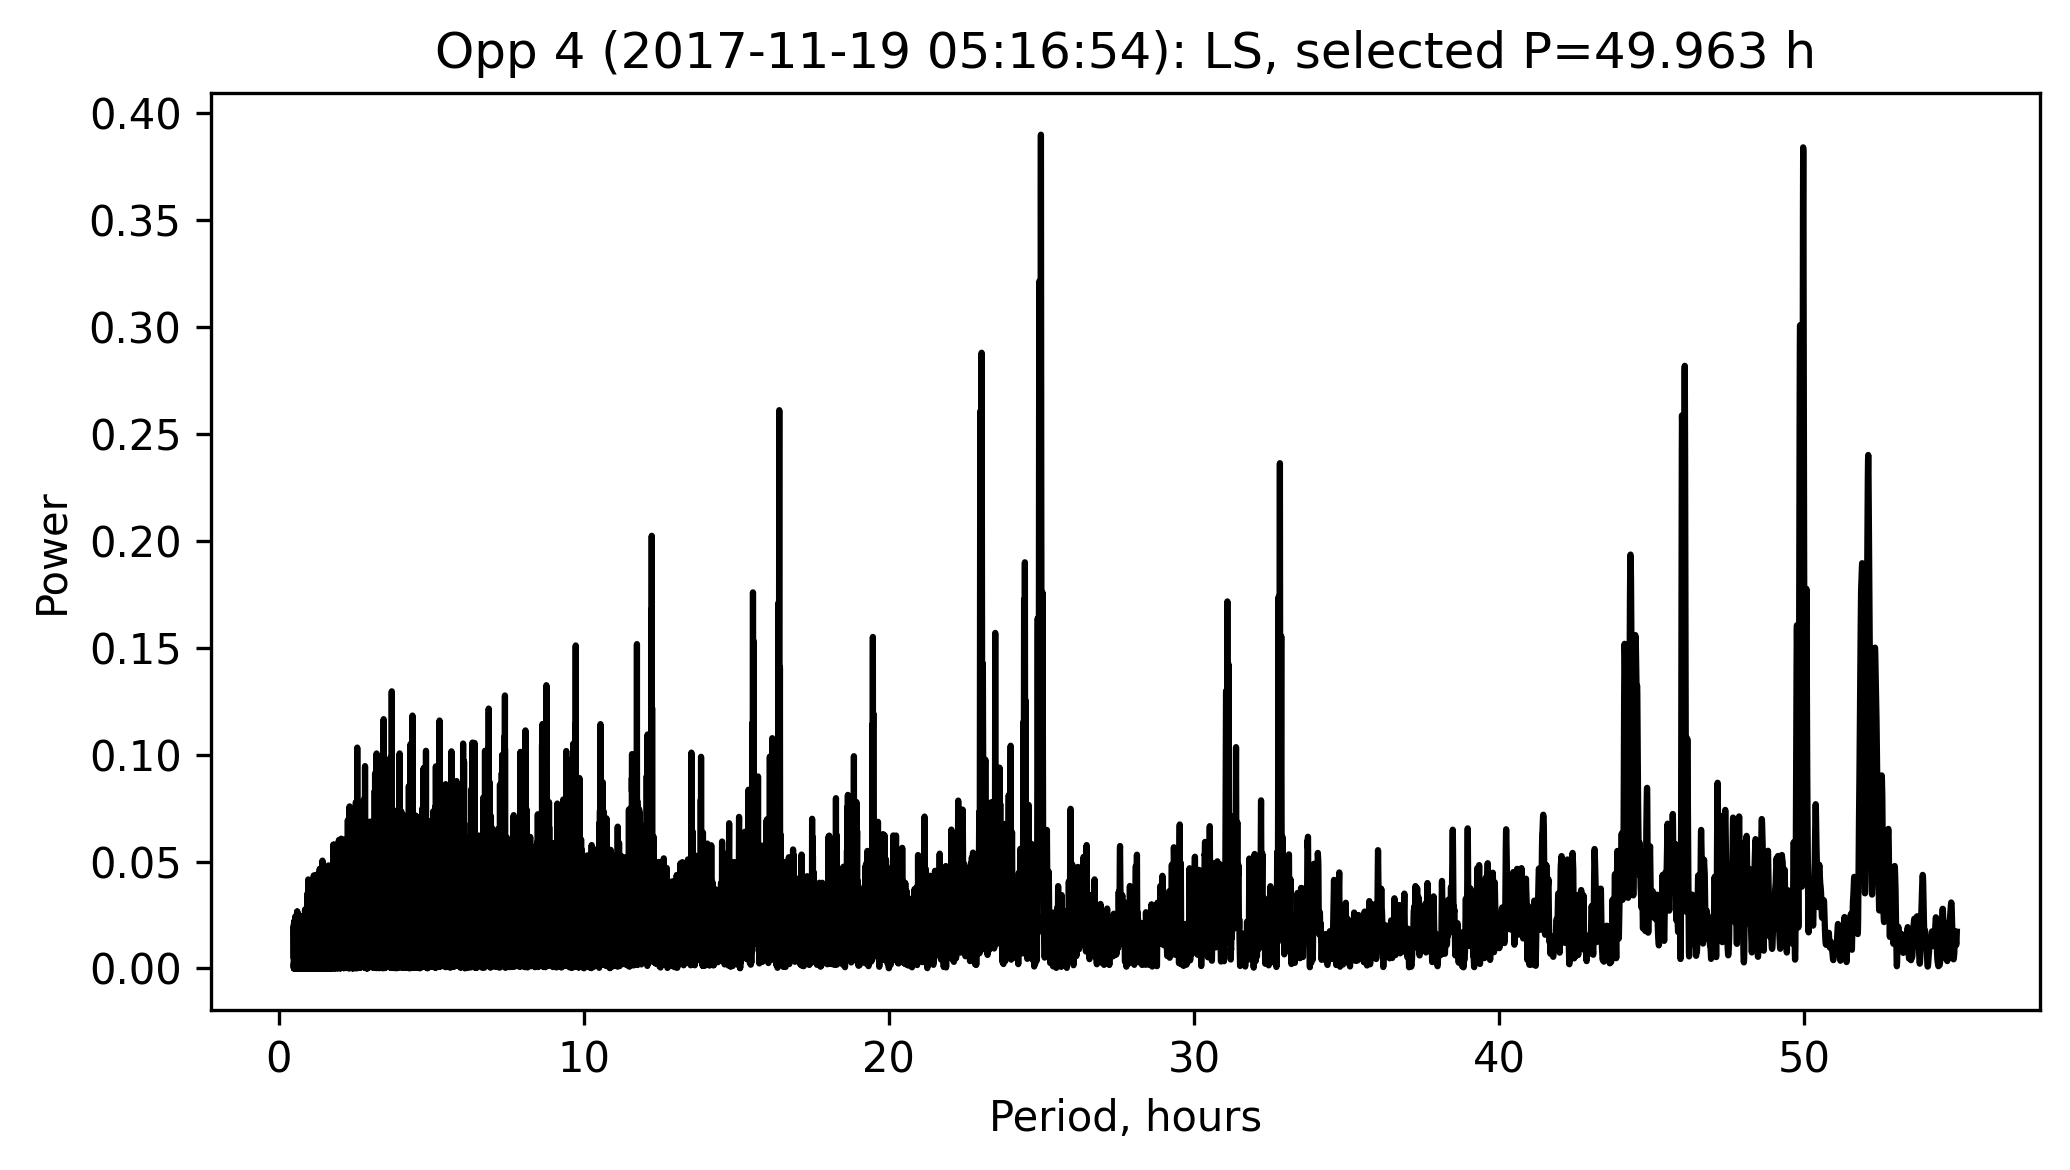

Opposition 5 (2022-01-30 05:16:54): top periods (hours)
      Period     power
0  24.990570  0.288388
1  49.982795  0.286832
2  24.989293  0.284902
3  24.991848  0.284316
4  49.977684  0.282313
Opposition 5: selected period = 49.9828 h; reason: top period is single-peaked; switched to candidate near 2x period (P1=24.9906 h, P2=49.9828 h)


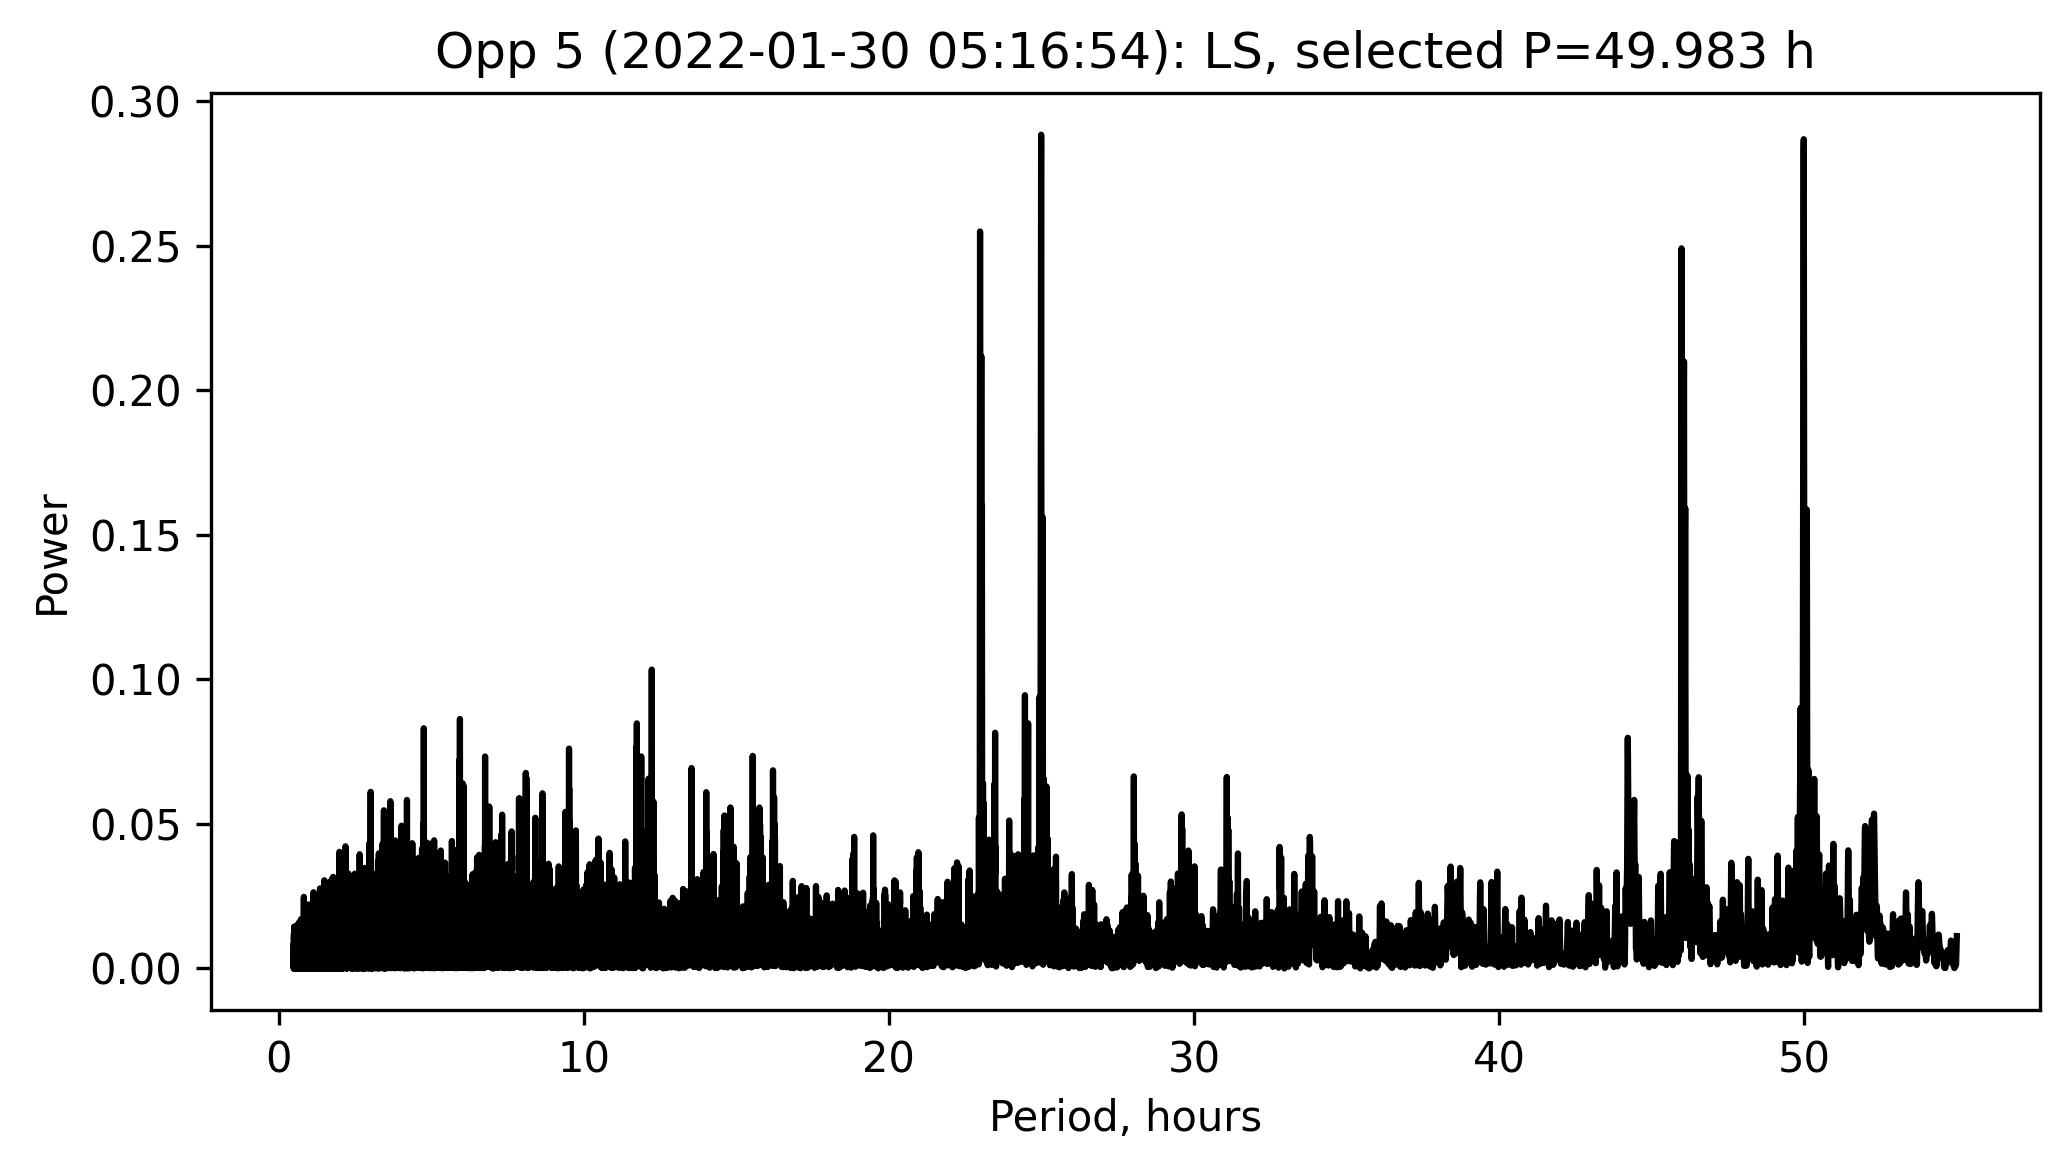

c:\Users\kn18001\Documents\Asteroids\Combined-dataset-period-analysis\asteroid_ls.py:591: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=1)


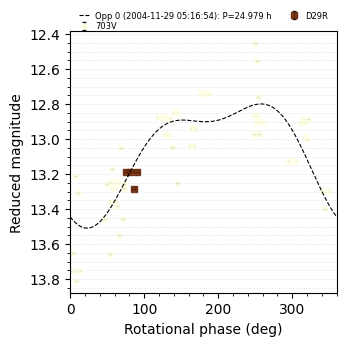

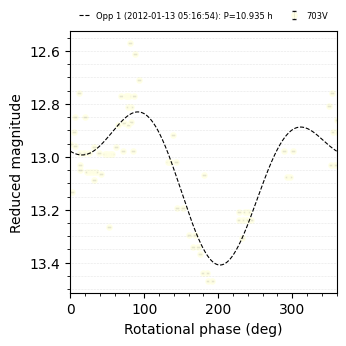

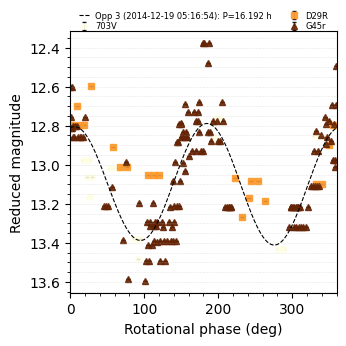

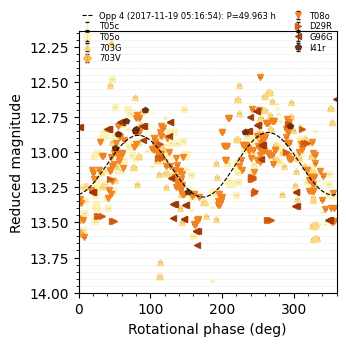

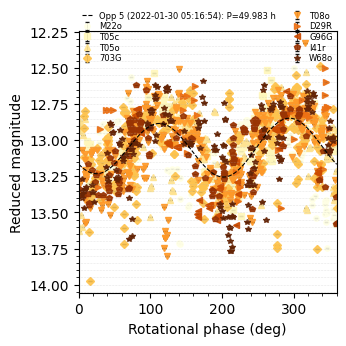

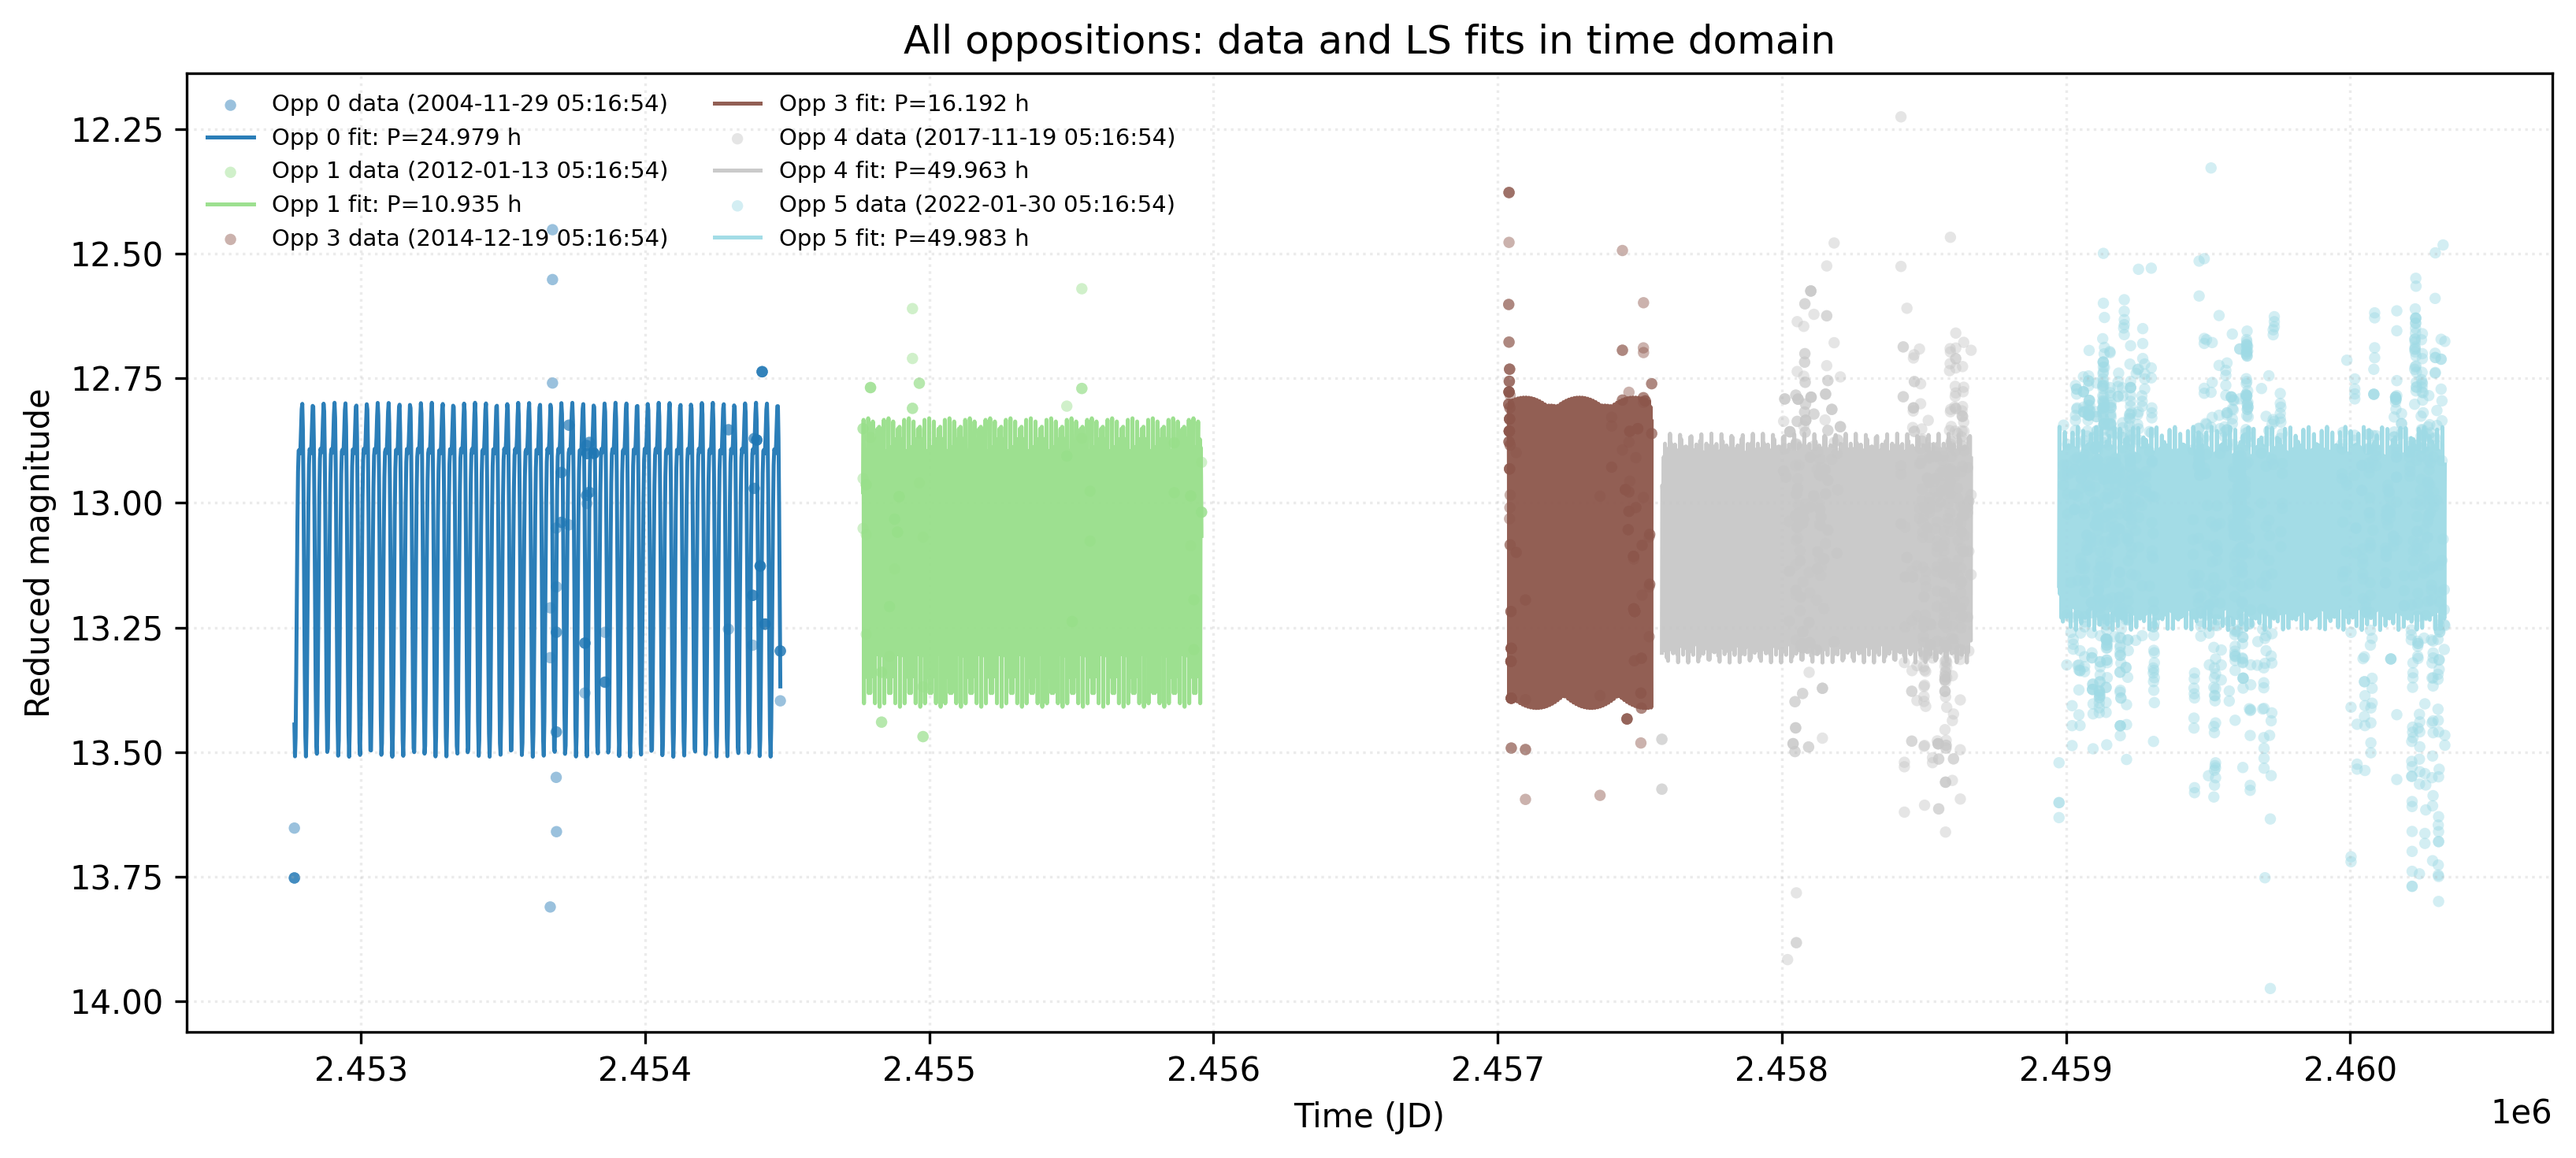

In [8]:
Asteroid_number= 3173
path_of_dict = r"../Asteroid_data/Plots_and_data/{}_data_compile_fix_G1G2.pkl".format(Asteroid_number)
with open(path_of_dict, 'rb') as file:
        # Load the data from the file
        dict_sheets = pickle.load(file)


pipe = AsteroidLSPipeline(dict_sheets, Asteroid_number=Asteroid_number)

opp_data = pipe.reading_data(
    split_oppositions=True,
    opposition_method="horizons",
    min_obs_per_opposition=50,
)

opp_ls = pipe.LS_initiate_per_opposition(
    opposition_data=opp_data,
    nterms=2,
    peak_idx=0,
    minf = 1 / (55 / 24),
    double_period_tol=0.12,
)

pipe.visualize_ls_per_opposition(opp_ls)
pipe.visualize_time_series_all_oppositions(opp_ls)